## Анализ маркетплейса: поиск точек роста и оптимизация маркетинга

 Краткое описание задачи: исследование поведения пользователей, эффективности каналов привлечения и монетизации на основе данных за 2024 год. Цель — выявить причины стагнации выручки и сформулировать рекомендации по восстановлению роста.

## Бизнес-контекст

Продукт демонстрировал уверенный рост в первой половине 2024 года: аудитория выросла в 3.5 раза, выручка — почти в 4 раза. Однако с сентября ключевые метрики начали снижаться, несмотря на сохранение высокой активности пользователей.

**Задача анализа**: понять, что изменилось во второй половине года, и найти точки для восстановления монетизации без увеличения маркетингового бюджета.

**Ключевые вопросы**:
- Какие каналы привлечения приносят прибыль, а какие — убыточны?
- На каких этапах воронки теряются пользователи?
- Какие сегменты аудитории стоит масштабировать, а какие — оптимизировать?

# Описание данных

Анализ проведён на основе четырёх датасетов, описывающих поведение пользователей, заказы и маркетинговые расходы:

## Таблица `Users`

| Поле              | Описание                                       |
|-------------------|------------------------------------------------|
| `user_id`         | Уникальный идентификатор пользователя.         |
| `registration_date` | Дата регистрации пользователя.                |
| `age`             | Возраст пользователя.                          |
| `gender`          | Пол.                                |
| `region`          | Регион.                                        |
| `acq_channel`     | Канал привлечения.                             |
| `buyer_segment`   | Сегмент покупателя.                            |
| `cohort_week`     | Неделя привлечения.|
| `cohort_month`    | Месяц привлечения. |

---

## Таблица `Events`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `event_id`    | Уникальный идентификатор события.                                        |
| `user_id`     | Идентификатор пользователя.                                              |
| `event_date`  | Дата события.                                                            |
| `event_type`  | Тип события.   |
| `os`          | Операционная система.               |
| `device`      | Тип устройства.                                |
| `product_name`| Наименование товара, к которому относится событие (если применимо).      |
| `event_week`  | Неделя события.                                          |
| `event_month` | Месяц события .                                           |

---

## Таблица `Orders`

| Поле          | Описание                                                                 |
|---------------|--------------------------------------------------------------------------|
| `order_id`    | Уникальный идентификатор заказа.                                         |
| `user_id`     | Идентификатор пользователя, который сделал заказ |
| `order_date`  | Дата и время оформления заказа.                                          |
| `product_name`| Наименование товара.                                                     |
| `quantity`    | Количество единиц товара в заказе.                                       |
| `unit_price`  | Цена за одну единицу товара.                                             |
| `total_price` | Итоговая сумма заказа.                                                   |
| `category_name` | Наименование категории товара.                                         |
| `order_week`  | Неделя заказа.                                           |
| `order_month` | Месяц заказа.                                            |


## Таблица `Campaign_costs`

| Поле         | Описание                                                                 |
|--------------|--------------------------------------------------------------------------|
| `acq_channel`| Канал привлечения.  |
| `spend_month`| Месяц, в который был потрачен бюджет (отражает период, в котором были привлечены пользователи)                      |
| `budget`     | Маркетинговый бюджет (в денежном выражении), потраченный на данный канал в указанном месяце.                           |



**Дополнительно**:
- Выручка маркетплейса рассчитывается как 5% от `total_price` каждого заказа.
- Все временные метки приведены к единому формату `datetime`.
- Данные отфильтрованы по валидным пользователям (97.1% выручки генерируется зарегистрированными пользователями).

## Описание событий в `events`

| Событие             | Описание                                                                                  |
|---------------------|-------------------------------------------------------------------------------------------|
| `page_view`         | Открытие любой страницы сайта или приложения пользователем.                                |
| `product_view`      | Просмотр страницы конкретного товара.                                                     |
| `product_click`     | Клик по товару (например, из списка товаров или на баннере).                              |
| `add_to_cart`       | Добавление товара в корзину.                                                              |
| `remove_from_cart`  | Удаление товара из корзины.                                                               |
| `search`            | Выполнение поиска по сайту или приложению.                                                |
| `filter_apply`      | Применение фильтра (например, по цене, бренду, категории).                                |
| `checkout_start`    | Начало оформления заказа (переход к оформлению корзины).                                  |
| `checkout_complete` | Завершение оформления заказа (не гарантирует покупку, покупка зависит от факта оплаты).                                          |
| `user_login`        | Вход пользователя в личный кабинет или аккаунт.                                           |
| `user_logout`       | Выход пользователя из аккаунта.                                                           |
| `wishlist_add`      | Добавление товара в список желаемого (wishlist).                                          |
| `category_view`     | Просмотр страницы категории товаров.                                                      |
| `banner_click`      | Клик по рекламному баннеру на сайте или в приложении.                                     |
| `promo_view`        | Просмотр промо-акции или специального предложения.                                        |


**Примечание**: Исходные данные анонимизированы. Для воспроизведения анализа достаточно структуры таблиц, описанной выше.

# Блок кода и расчета метрик

In [ ]:
# 1. Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import plotly.express as px
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
from scipy.stats import ttest_ind

In [ ]:
# 2. Загрузка данных (пути маскированы)
ORDERS_PATH = 'data/pa_marketplace_orders.csv'
CAMPAIGNS_PATH = 'data/pa_marketplace_campaign_costs.csv'
USERS_PATH = 'data/pa_marketplace_users.csv'
EVENTS_PATH = 'data/pa_marketplace_events.csv'

orders = pd.read_csv(ORDERS_PATH)
campaigns = pd.read_csv(CAMPAIGNS_PATH, index_col=0)
users = pd.read_csv(USERS_PATH)
events = pd.read_csv(EVENTS_PATH)

In [ ]:
# # 3. Валидация: проверка целостности данных, типов данных, дубликатов, пропусков в таблицах:
for name, df in [("users", users), ("events", events), ("orders", orders), ("campaigns", campaigns)]:
    print(f"\n{name.upper()}")
    print(df.info())
    print("\nПропуски:")
    print(df.isnull().sum())
    print("\nДубликаты строк:", df.duplicated().sum())
    if name != "campaigns":
        print("Дубликаты по user_id:", df['user_id'].duplicated().sum())


USERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44151 entries, 0 to 44150
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            44151 non-null  int64 
 1   registration_date  44151 non-null  object
 2   age                44151 non-null  int64 
 3   gender             44151 non-null  object
 4   region             44151 non-null  object
 5   acq_channel        44151 non-null  object
 6   buyer_segment      44151 non-null  object
 7   cohort_week        44151 non-null  object
 8   cohort_month       44151 non-null  object
dtypes: int64(2), object(7)
memory usage: 3.0+ MB
None

Пропуски:
user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64

Дубликаты строк: 0
Дубликаты по user_id: 0

EVENTS
<class 'pandas.core.frame.Data

In [ ]:
# 4. Предобработка: приведение к единому формату
# Приведение дат
users['registration_date'] = pd.to_datetime(users['registration_date'])
events['event_date'] = pd.to_datetime(events['event_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Корректировка total_price (были расхождения в исходных данных)
orders['total_price_fixed'] = orders['quantity'] * orders['unit_price']
orders['revenue'] = orders['total_price_fixed'] * 0.05  # Комиссия маркетплейса 5%

# Фильтрация по валидным пользователям
valid_user_ids = set(users['user_id'])

# Заказы и события от известных пользователей
orders_clean = orders[orders['user_id'].isin(valid_user_ids)].copy()
events_clean = events[events['user_id'].isin(valid_user_ids)].copy()

# Удаляем 37 записей до первой регистрации
first_reg_ts = users['registration_date'].min()
events_clean = events_clean[events_clean['event_date'] >= first_reg_ts].copy()

# Оставляем только бюджеты 2024 года (в данных есть бюджеты на 2025)
campaigns_2024 = campaigns[campaigns['spend_month'] != '2025-01-01'].copy()

# Проверка доли выручки от известных пользователей
total_revenue_all = orders['total_price'].sum() * 0.05
total_revenue_user = orders_clean['total_price'].sum() * 0.05

print(f"Доля выручки от известных пользователей: {total_revenue_user / total_revenue_all:.1%}")

Доля выручки от известных пользователей: 97.1%


**Предобработка данных перед анализом:**

Исходные данные требовали очистки и унификации, чтобы метрики (ARPU, CAC, Retention) отражали реальное поведение клиентов, а не артефакты сбора.

| Проблема | Решение | Пояснение |
|----------|---------|-------------------|
| Разные форматы дат | Приведение `registration_date`, `event_date`, `order_date` к `datetime` | Корректная временная агрегация и когортный анализ |
| Расхождения в `total_price` | Пересчёт по формуле `quantity × unit_price` (исправлено 74 записи) | Точность финансовых метрик: выручка, AOV, LTV |
| Неизвестные пользователи | Фильтрация заказов и событий по валидным `user_id` из `users` | 97,1% выручки учтено — выборка репрезентативна |
| События до регистрации | Удалено 37 записей с `event_date < first_registration` | Исключение ложных активностей в воронке |
| Бюджеты 2025 года | Исключены из расчёта `CAC` | Корректное сопоставление затрат и когорт 2024 года |

**Итог**

После предобработки получены чистые датасеты `orders_clean` и `events_clean`, на основе которых рассчитываются все продуктовые и финансовые метрики. Это гарантирует, что выводы опираются на согласованные и верифицированные данные.

### 2. Анализ ключевых метрик продукта

#### **Контекст задачи**

Проведена верхнеуровневая оценка состояния маркетплейса на основе агрегированных данных. 

**Цель** — выявить тренды в динамике основных метрик, оценить соответствие продукта базовым ожиданиям и зафиксировать ранние сигналы роста или риска.

#### **Методология**

**Модель монетизации**: выручка маркетплейса = 5% комиссии от total_price каждого заказа.

**Анализируемые метрики**:

- **Финансовые**: Revenue, GMV, AOV, ARPU, ARPPU
- **Активность**: MAU, DAU, Stickiness (DAU/MAU)
- **Конверсия**: CR (активные пользователи → покупатели)
    
**Подход**: агрегация по месяцам, визуализация трендов, сравнение полугодий. Сегментация на этом этапе не применялась — фокус на общей картине.

In [ ]:

# Расчёт ключевых метрик: монетизация и активность

# Цель: оценить динамику выручки, среднего чека и вовлечённости 
# в разрезе месяцев для выявления трендов и аномалий

# Группировка заказов по месяцу для временной агрегации
orders_clean['order_month'] = orders_clean['order_date'].dt.to_period('M').astype(str)

# MAU (Monthly Active Users): база для расчёта относительных метрик (ARPU, CR)
# Считается по событиям, так как активность ≠ покупка
mau_by_month = events_clean.groupby(
    events_clean['event_date'].dt.to_period('M')
).size().rename('mau').reset_index()
mau_by_month['month_str'] = mau_by_month['event_date'].astype(str)

# Агрегация финансовых показателей по заказам:
# • revenue — комиссия маркетплейса (5% от GMV)
# • gmv — общий объём транзакций
# • paying_users — уникальные покупатели для ARPPU
monthly_metrics = (orders_clean.groupby('order_month').agg(
        revenue=('revenue', 'sum'),
        gmv=('total_price_fixed', 'sum'),
        orders=('order_id', 'count'),
        paying_users=('user_id', 'nunique')
    ).reset_index())

# Объединение с MAU для расчёта метрик на активного пользователя
monthly_metrics = monthly_metrics.merge(
    mau_by_month[['month_str', 'mau']],
    left_on='order_month',
    right_on='month_str',
    how='left'
).drop(columns=['month_str'])

# Расчёт относительных метрик:
# • ARPU = выручка / все активные (оценка монетизации аудитории)
# • AOV = GMV / заказы (стабильность среднего чека)
# • ARPPU = выручка / платящие (глубина монетизации)
# • PUR = платящие / все активные (конверсия в покупку)
monthly_metrics['arpu'] = monthly_metrics['revenue'] / monthly_metrics['mau']
monthly_metrics['aov'] = monthly_metrics['gmv'] / monthly_metrics['orders']
monthly_metrics['arppu'] = monthly_metrics['revenue'] / monthly_metrics['paying_users']
monthly_metrics['pur'] = monthly_metrics['paying_users'] / users.shape[0]

print("Основные метрики по месяцам:")
display(monthly_metrics[['order_month', 'revenue', 'gmv', 'aov', 'arpu', 'arppu', 'pur']].round(2))

Основные метрики по месяцам:


,order_month,revenue,gmv,aov,arpu,arppu,pur
0,2024-01,623485.59,12469711.79,13408.29,27.18,1420.24,0.01
1,2024-02,1243809.28,24876185.68,13512.32,27.82,1547.03,0.02
2,2024-03,1883490.41,37669808.22,13956.95,29.58,1669.76,0.03
3,2024-04,2093035.31,41860706.19,13742.85,29.28,1626.29,0.03
4,2024-05,2415453.18,48309063.63,14150.28,31.45,1773.46,0.03
5,2024-06,2048813.42,40976268.37,13695.28,28.57,1705.92,0.03
6,2024-07,2367890.53,47357810.51,14273.00,30.99,1755.29,0.03
7,2024-08,2414997.47,48299949.38,14636.35,30.28,1791.54,0.03
8,2024-09,1892676.34,37853526.88,14019.82,26.11,1663.16,0.03
9,2024-10,1666191.66,33323833.19,13838.80,26.74,1714.19,0.02


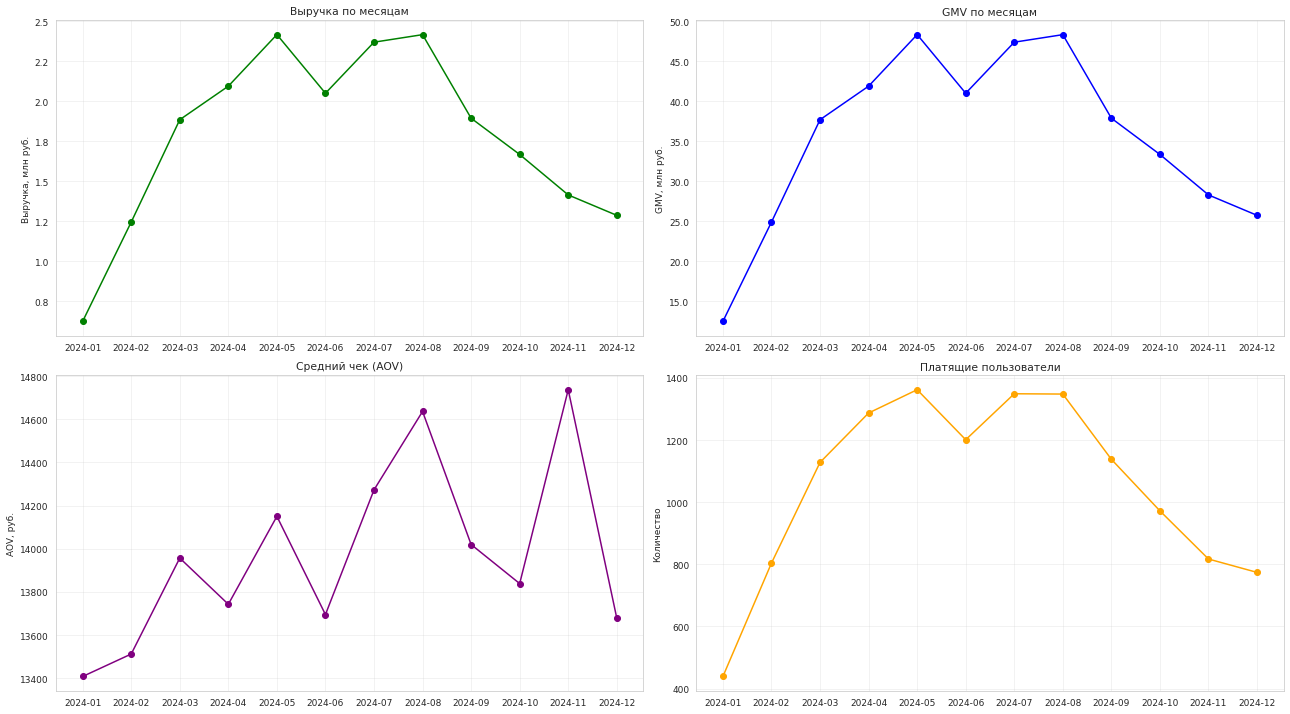

In [ ]:
# Визуализация ключевых метрик: поиск трендов и аномалий

# Цель: оценить динамику монетизации и спроса, выявить точки роста 
# и ранние сигналы риска. Графики сгруппированы по типам метрик.

plt.figure(figsize=(18, 10))

# 1. Выручка (Revenue) — основной индикатор монетизации
# Ищем: сезонность, тренды, точки перелома динамики
plt.subplot(2, 2, 1)
plt.plot(monthly_metrics['order_month'], monthly_metrics['revenue'], marker='o', color='green')
plt.title('Выручка по месяцам')
plt.ylabel('Выручка, млн руб.')
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))

# 2. GMV (Gross Merchandise Value) — общий объём транзакций
# Показывает масштаб бизнеса независимо от комиссии
plt.subplot(2, 2, 2)
plt.plot(monthly_metrics['order_month'], monthly_metrics['gmv'], marker='o', color='blue')
plt.title('GMV по месяцам')
plt.ylabel('GMV, млн руб.')
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}'))

# 3. AOV (Average Order Value) — средний чек
# Индикатор качества спроса: растёт ли ценность покупок?
plt.subplot(2, 2, 3)
plt.plot(monthly_metrics['order_month'], monthly_metrics['aov'], marker='o', color='purple')
plt.title('Средний чек (AOV)')
plt.ylabel('AOV, руб.')
plt.grid(True, alpha=0.3)

# 4. Платящие пользователи — база монетизации
# Показывает, сколько уникальных клиентов генерируют выручку
plt.subplot(2, 2, 4)
plt.plot(monthly_metrics['order_month'], monthly_metrics['paying_users'], marker='o', color='orange')
plt.title('Платящие пользователи')
plt.ylabel('Количество')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Расчёт метрик активности и вовлечённости пользователей

# Цель: оценить динамику аудитории, частоту возвратов и конверсию 
# в покупку для выявления трендов и точек роста


# 1. MAU (Monthly Active Users)

# Считаем, сколько уникальных пользователей проявили активность в каждом месяце
mau = (events_clean.groupby(events_clean['event_date'].dt.to_period('M')).size().reset_index(name='mau'))
mau['month'] = mau['event_date'].astype(str)
mau = mau.sort_values('month').reset_index(drop=True)

# 2. DAU (Daily Active Users) — для расчёта Stickiness

# Показывает, сколько людей заходят в приложение каждый день

dau = (events_clean.groupby(events_clean['event_date'].dt.date).size().reset_index(name='dau'))
dau.rename(columns={'event_date': 'day'}, inplace=True)

# 3. Stickiness — насколько продукт «прилипает»

# Отношение среднего DAU к MAU: чем выше, тем чаще пользователи возвращаются
dau_with_month = dau.copy()
dau_with_month['month'] = pd.to_datetime(dau_with_month['day']).dt.to_period('M').astype(str)
avg_dau = dau_with_month.groupby('month')['dau'].mean().reset_index(name='avg_dau')
stickiness = pd.merge(mau[['month', 'mau']], avg_dau, on='month', how='left')
stickiness['stickiness_ratio'] = stickiness['avg_dau'] / stickiness['mau']

# 4. Конверсия в покупку (CR) — сколько активных становятся платящими

# Считаем уникальных покупателей по месяцам и делим на активных
paying_monthly = (orders_clean.groupby(orders_clean['order_date'].dt.to_period('M')).agg(paying_users=('user_id', 'nunique')).reset_index())
paying_monthly['month'] = paying_monthly['order_date'].astype(str)

cr_data = pd.merge(mau[['month', 'mau']], paying_monthly[['month', 'paying_users']], on='month', how='left')
cr_data['cr'] = cr_data['paying_users'] / cr_data['mau']

# 5. Сводим всё в одну таблицу для анализа 
activity_metrics = pd.merge(stickiness, cr_data[['month', 'cr']], on='month')
activity_metrics = activity_metrics.sort_values('month').reset_index(drop=True)

print("Метрики активности по месяцам:")
display(activity_metrics[['month', 'mau', 'avg_dau', 'stickiness_ratio', 'cr']].round(4))

Метрики активности по месяцам:


,month,mau,avg_dau,stickiness_ratio,cr
0,2024-01,22939,764.6333,0.0333,0.0191
1,2024-02,44704,1541.5172,0.0345,0.0180
2,2024-03,63674,2054.0000,0.0323,0.0177
3,2024-04,71475,2382.5000,0.0333,0.0180
4,2024-05,76812,2477.8065,0.0323,0.0177
5,2024-06,71710,2390.3333,0.0333,0.0167
6,2024-07,76406,2464.7097,0.0323,0.0177
7,2024-08,79763,2573.0000,0.0323,0.0169
8,2024-09,72489,2416.3000,0.0333,0.0157
9,2024-10,62306,2009.8710,0.0323,0.0156


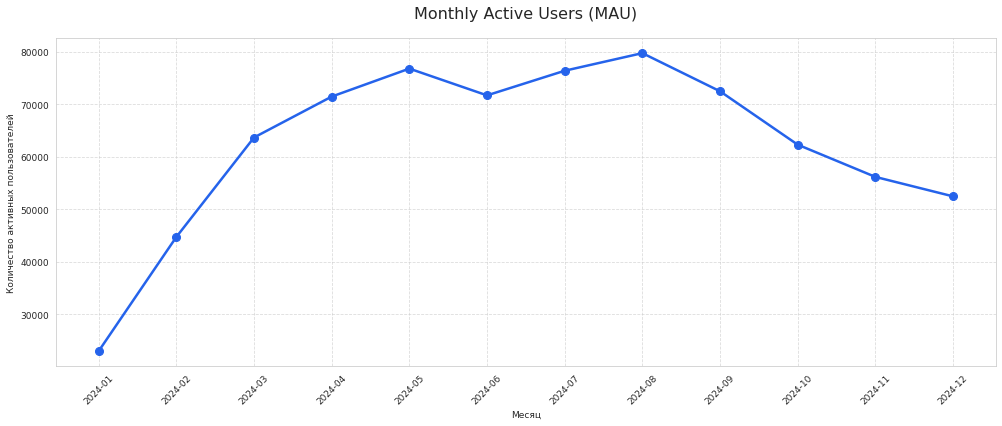

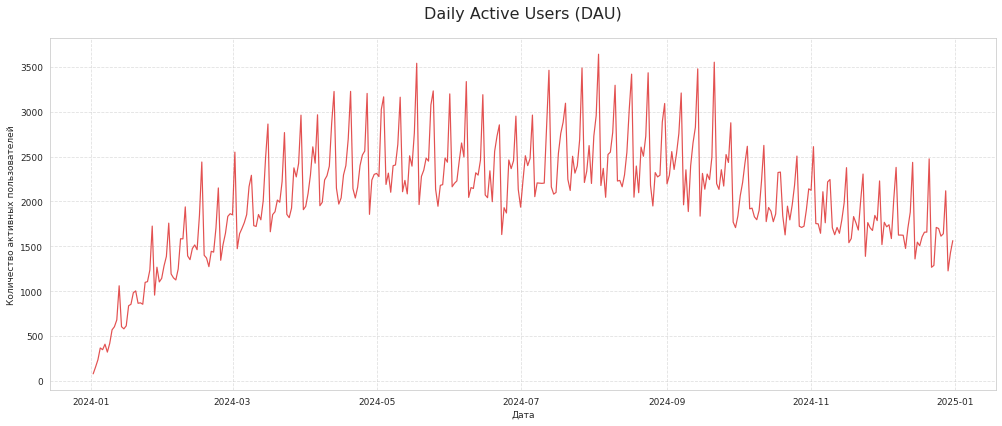

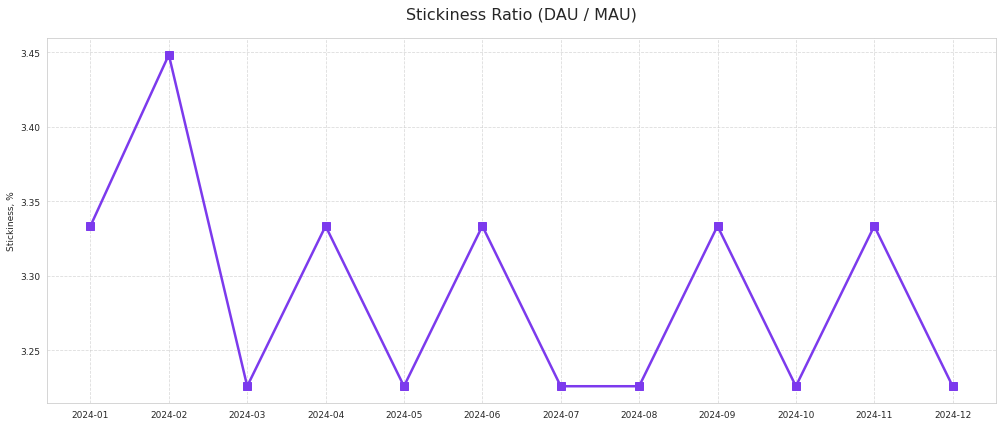

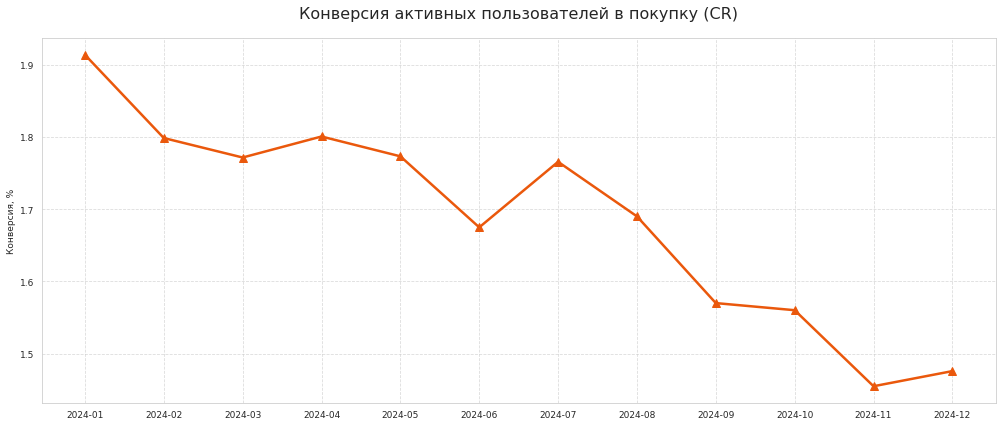

In [ ]:
# Визуализация вовлечённости: как аудитория взаимодействует с продуктом во времени

# Цель: оценить стабильность аудитории, частоту возвратов и способность конвертировать активность в покупки

# 1. Месячная активность — масштаб аудитории
# Показывает, сколько уникальных пользователей проявили интерес к продукту
plt.figure(figsize=(14, 6))
plt.plot(activity_metrics['month'], activity_metrics['mau'], marker='o', linewidth=2.5, markersize=8, color='#2563eb')
plt.title('Monthly Active Users (MAU)', fontsize=16, pad=20)
plt.ylabel('Количество активных пользователей')
plt.xlabel('Месяц')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 2. Ежедневная активность продукта
# Детализация по дням помогает увидеть краткосрочные паттерны и аномалии
plt.figure(figsize=(14, 6))
plt.plot(dau['day'], dau['dau'], color='#dc2626', alpha=0.8, linewidth=1.2)
plt.title('Daily Active Users (DAU)', fontsize=16, pad=20)
plt.ylabel('Количество активных пользователей')
plt.xlabel('Дата')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 3. Лояльность аудитории: насколько продукт «прилипает»
# Отношение DAU к MAU показывает, как часто пользователи возвращаются
plt.figure(figsize=(14, 6))
plt.plot(activity_metrics['month'], activity_metrics['stickiness_ratio'] * 100,
         marker='s', linewidth=2.5, markersize=8, color='#7c3aed')
plt.title('Stickiness Ratio (DAU / MAU)', fontsize=16, pad=20)
plt.ylabel('Stickiness, %')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Эффективность монетизации: конверсия в покупку
# Ключевой индикатор: какая доля активных пользователей совершает транзакцию
plt.figure(figsize=(14, 6))
plt.plot(activity_metrics['month'], activity_metrics['cr'] * 100,
         marker='^', linewidth=2.5, markersize=8, color='#ea580c')
plt.title('Конверсия активных пользователей в покупку (CR)', fontsize=16, pad=20)
plt.ylabel('Конверсия, %')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Динамика ключевых метрик (2024)

Продукт демонстрирует уверенный рост в первой половине года, но сталкивается с тревожными сигналами во второй.

**Положительные тенденции:**
- Выручка выросла почти в **4×** (янв → май)
- Аудитория (MAU) увеличилась с 22 939 до 79 763 (+242%)
- Средний чек (AOV) стабилен на уровне ~14 000 руб.
- Конверсия достигла пика в апреле: 43,5%

**Тревожные сигналы (сентябрь–декабрь):**
- Выручка упала на 47%
- Конверсия снизилась до 1,48% (−18% от пика)
- Ежедневная активность (DAU) сократилась на 34%

При этом Stickiness Ratio остаётся стабильным — гипотеза массового оттока исключена.

---

#### Ключевой инсайт
Аудитория растёт, но монетизация падает: конверсия снизилась с 1,80% до 1,48% при стабильном MAU. Это указывает на проблему качества трафика или UX на этапе покупки, а не на отток пользователей.

### 3. Оценка метрик монетизации и юнит-экономики

**Бизнес-контекст**

Активный рост аудитории (MAU вырос в 3,5 раза) не привёл к пропорциональному росту выручки. Возникает гипотеза, что проблема кроется в качестве привлекаемого трафика или структуре затрат. Чтобы это проверить, нужно перейти от метрик вовлечённости к показателям рентабельности.

**Задача анализа**

Определить, насколько эффективно продукт монетизирует привлечённых пользователей. Мы оценим, покрывает ли пожизненная ценность клиента (LTV) затраты на его привлечение (CAC) в стандартный для маркетплейсов горизонт в 28 дней.

**Что будем считать**:
- **CAC** (Customer Acquisition Cost) — стоимость привлечения одного нового пользователя.
- **LTV** (Lifetime Value) — совокупная выручка с пользователя за первые 4 недели.
- **ROI** (Return on Investment) — коэффициент окупаемости маркетинговых вложений.
- **Payback Period** — период, за который когорта пользователей полностью отбивает затраты на своё привлечение.

In [ ]:

# Коортный анализ: оценка окупаемости привлечения (28-дневный горизонт)

# Цель: понять, покрывает ли пожизненная ценность пользователя (LTV) 
# затраты на его привлечение (CAC) в разрезе месячных когорт

# 1. Подготовка: формируем признак «месяц привлечения»
# Это ключ для группировки пользователей в когорты
users['cohort_month'] = users['registration_date'].dt.to_period('M').astype(str)

# 2. Размер когорт: сколько новых пользователей пришло в каждом месяце
cohort_sizes = (users.groupby('cohort_month').size().reset_index(name='new_users'))

# 3. Затраты на привлечение (CAC)
# Суммируем маркетинговый бюджет по месяцам и каналам
monthly_budget = (campaigns_2024.groupby('spend_month')['budget'].sum().reset_index(name='total_budget'))
monthly_budget['spend_month'] = pd.to_datetime(monthly_budget['spend_month']).dt.to_period('M').astype(str)

# Сопоставляем бюджет с размером когорты → считаем CAC
cac_cohorts = pd.merge(monthly_budget, cohort_sizes, left_on='spend_month', right_on='cohort_month', how='inner')
cac_cohorts['cac'] = cac_cohorts['total_budget'] / cac_cohorts['new_users']

# 4. Доход от когорты (LTV)
# Считаем суммарную выручку с каждого пользователя (комиссия 5% от total_price)
user_revenue = (orders_clean.groupby('user_id').agg(revenue=('revenue', 'sum')).reset_index())

# Присоединяем выручку к пользователям, заполняем нулями для неплатящих
users_with_revenue = pd.merge(users, user_revenue, on='user_id', how='left')
users_with_revenue['revenue'] = users_with_revenue['revenue'].fillna(0)

# Агрегируем доход по когортам (месяц регистрации)
cohort_revenue = (users_with_revenue.groupby('cohort_month').agg(total_revenue=('revenue', 'sum')).reset_index())

# 5. Итоговые метрики: CAC, LTV, ROI по когортам
cohort_metrics = pd.merge(cac_cohorts[['cohort_month', 'new_users', 'cac']], cohort_revenue, on='cohort_month', how='inner')

# LTV = суммарная выручка когорты / число пользователей в когорте
cohort_metrics['ltv'] = cohort_metrics['total_revenue'] / cohort_metrics['new_users']

# ROI = (LTV − CAC) / CAC → показывает окупаемость вложений
cohort_metrics['roi'] = (cohort_metrics['ltv'] - cohort_metrics['cac']) / cohort_metrics['cac']

print("Когортные метрики CAC и ROI:")
display(cohort_metrics.round(2))

Когортные метрики CAC и ROI:


,cohort_month,new_users,cac,total_revenue,ltv,roi
0,2024-01,2985,394.46,2105090.29,705.22,0.79
1,2024-02,2711,391.51,2052689.16,757.17,0.93
2,2024-03,2965,393.82,2481937.70,837.08,1.13
3,2024-04,2905,395.09,2456668.32,845.67,1.14
4,2024-05,3066,399.65,2246673.72,732.77,0.83
5,2024-06,2810,402.29,1891357.64,673.08,0.67
6,2024-07,4388,404.84,2480705.40,565.34,0.40
7,2024-08,4431,408.86,1883228.28,425.01,0.04
8,2024-09,4466,407.68,1446349.32,323.86,-0.21
9,2024-10,4440,407.84,1107371.11,249.41,-0.39


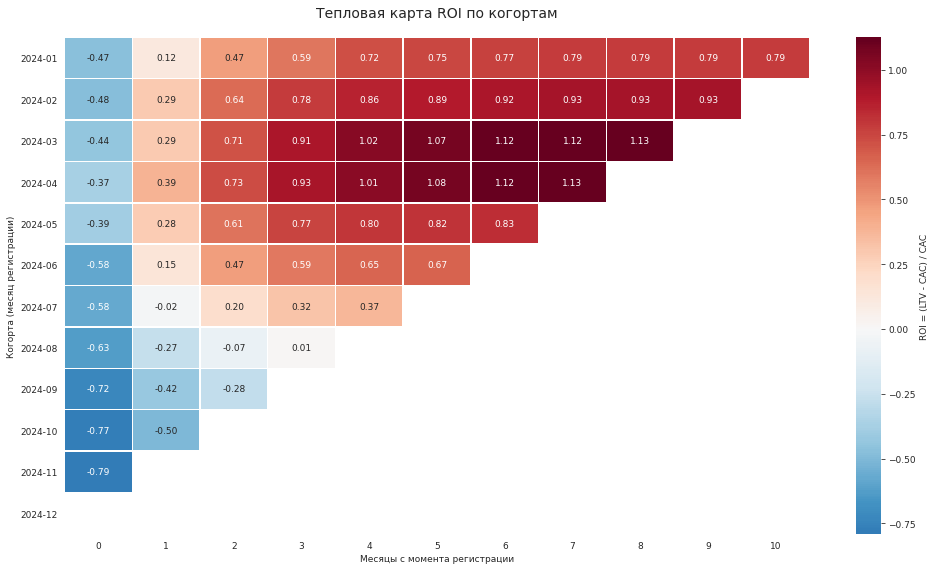

In [ ]:

# Когортный анализ: динамика окупаемости во времени

# Цель: понять, за какой период когорты пользователей 
# возвращают затраты на своё привлечение (Payback Period)

# 1. Связываем заказы с когортами пользователей
# Чтобы отследить, как растёт доход от каждой группы во времени
orders_with_cohort = orders_clean.merge(users[['user_id', 'cohort_month']], on='user_id', how='left')

# 2. Рассчитываем «возраст» заказа относительно когорты
# months_since_registration = 0 → первый месяц после регистрации, 1 → второй и т.д.
orders_with_cohort['order_month_dt'] = pd.to_datetime(orders_with_cohort['order_month'])
orders_with_cohort['cohort_month_dt'] = pd.to_datetime(orders_with_cohort['cohort_month'])

orders_with_cohort['months_since_registration'] = (
    (orders_with_cohort['order_month_dt'].dt.year - orders_with_cohort['cohort_month_dt'].dt.year) * 12 +
    (orders_with_cohort['order_month_dt'].dt.month - orders_with_cohort['cohort_month_dt'].dt.month)
)

# Исключаем «отрицательный возраст» — заказы до регистрации (артефакты данных)
orders_with_cohort = orders_with_cohort[orders_with_cohort['months_since_registration'] >= 0]

# 3. Агрегируем выручку по когорте и месяцу жизни
ltv_by_cohort_month = (
    orders_with_cohort
    .groupby(['cohort_month', 'months_since_registration'])
    .agg(revenue_sum=('revenue', 'sum'))
    .reset_index()
)

# 4. Добавляем размер когорты для нормализации
cohort_sizes = users.groupby('cohort_month').size().reset_index(name='new_users')
ltv_by_cohort_month = pd.merge(ltv_by_cohort_month, cohort_sizes, on='cohort_month')

# LTV на одного пользователя = суммарная выручка когорты / число пользователей в ней
ltv_by_cohort_month['ltv_per_user'] = ltv_by_cohort_month['revenue_sum'] / ltv_by_cohort_month['new_users']

# 5. Формируем матрицу: строки = когорты, столбцы = месяцы жизни
ltv_matrix = ltv_by_cohort_month.pivot(index='cohort_month', columns='months_since_registration', values='ltv_per_user').fillna(0)

# Кумулятивный LTV: накопленная выручка от когорты к каждому месяцу
cumulative_ltv = ltv_matrix.cumsum(axis=1)

# 6. Считаем ROI: (Cumulative LTV − CAC) / CAC
cac_series = cohort_metrics.set_index('cohort_month')['cac']

# Разница между накопленным доходом и затратами
roi_matrix = cumulative_ltv.sub(cac_series, axis=0)
# Нормализуем: относительная окупаемость вложений
roi_matrix_normalized = roi_matrix.div(cac_series, axis=0)
 
# 7. Обрезаем матрицу до треугольника (логика когортного анализа)
# Когорта не может иметь данные «из будущего» — заполняем лишнее пропусками
max_months = min(11, roi_matrix_normalized.shape[1])
mask = np.zeros_like(roi_matrix_normalized.values, dtype=bool)
for i in range(len(roi_matrix_normalized)):
    for j in range(max_months):
        if j <= max_months - i - 1:
            mask[i, j] = True

roi_triangle = roi_matrix_normalized.where(mask)

# 8. Визуализация: тепловая карта окупаемости
plt.figure(figsize=(14, 8))
sns.heatmap(
    roi_triangle,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'ROI = (LTV - CAC) / CAC'}
)
plt.title('Тепловая карта ROI по когортам', fontsize=14, pad=20)
plt.xlabel('Месяцы с момента регистрации')
plt.ylabel('Когорта (месяц регистрации)')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

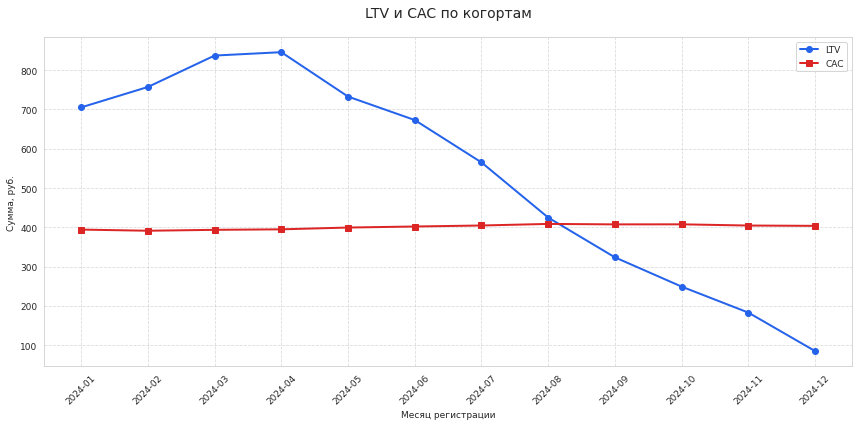

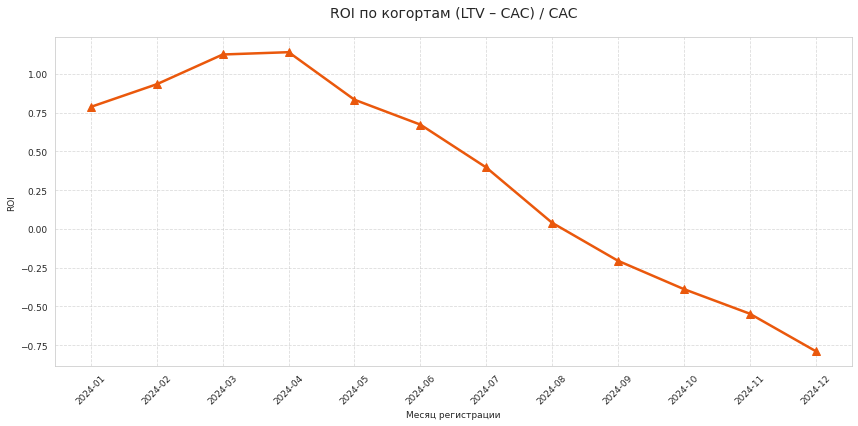

In [ ]:
# Визуализация юнит-экономики: окупаемость когорт во времени

# Цель: показать, как соотносятся затраты на привлечение (CAC) и пожизненная ценность пользователя (LTV), 
# а также динамика ROI

# 1. Подготовка данных для графика LTV vs CAC
# Берём финальное значение кумулятивного LTV для каждой когорты (последний столбец матрицы = суммарный доход за 28 дней)
ltv_final = cumulative_ltv.iloc[:, -1].reset_index(name='ltv').rename(columns={'index': 'cohort_month'})

# Извлекаем CAC по когортам из ранее рассчитанных метрик
cac_series = cohort_metrics.set_index('cohort_month')['cac'].reset_index(name='cac')

# Объединяем в одну таблицу для удобного построения графика
ltv_cac_plot = pd.merge(ltv_final, cac_series, on='cohort_month')

# 2. График: точка безубыточности когорт
# Показывает, когда накопленный доход от пользователя начинает превышать затраты на его привлечение
plt.figure(figsize=(12, 6))

# Линия LTV — накопленная выручка с пользователя за 28 дней
plt.plot(
    ltv_cac_plot['cohort_month'],
    ltv_cac_plot['ltv'],
    marker='o',
    linewidth=2,
    markersize=6,
    color='#2563eb',
    label='LTV'
)

# Линия CAC — стоимость привлечения одного пользователя
plt.plot(
    ltv_cac_plot['cohort_month'],
    ltv_cac_plot['cac'],
    marker='s',
    linewidth=2,
    markersize=6,
    color='#dc2626',
    label='CAC'
)

# Оформление: акцент на точке пересечения (момент окупаемости)
plt.title('LTV и CAC по когортам', fontsize=14, pad=20)
plt.ylabel('Сумма, руб.')
plt.xlabel('Месяц регистрации')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 3. График ROI: относительная эффективность вложений
# ROI = (LTV − CAC) / CAC: положительное значение = прибыль, отрицательное = убыток, ноль = точка безубыточности
plt.figure(figsize=(12, 6))

plt.plot(
    cohort_metrics['cohort_month'],
    cohort_metrics['roi'],
    marker='^',
    linewidth=2.5,
    markersize=8,
    color='#ea580c',
    label='ROI'
)

# Настройки 
plt.title('ROI по когортам (LTV – CAC) / CAC', fontsize=14, pad=20)
plt.ylabel('ROI')
plt.xlabel('Месяц регистрации')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

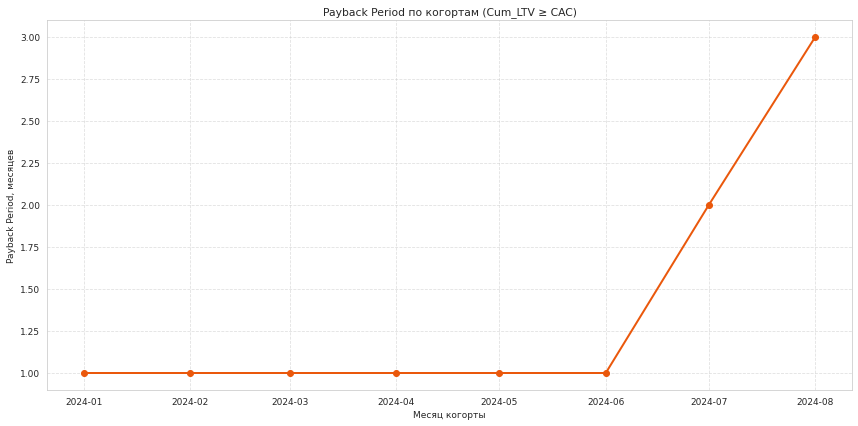

In [ ]:
# Расчёт периода окупаемости (Payback Period) по когортам

# Цель: определить, за сколько месяцев кумулятивный доход от когорты покрывает затраты на её привлечение (CAC)

# Создаём рабочие копии данных, чтобы не менять исходные датафреймы
users_temp = users.copy()
orders_clean_temp = orders_clean.copy()
cohort_metrics_temp = cohort_metrics.copy()

# Приводим временные метки к datetime
users_temp['cohort_month'] = pd.to_datetime(users_temp['cohort_month'])
orders_clean_temp['order_month'] = pd.to_datetime(orders_clean_temp['order_month'])
cohort_metrics_temp['cohort_month'] = pd.to_datetime(cohort_metrics_temp['cohort_month'])

# Связываем заказы с когортами пользователей по месяцу регистрации
# Это позволяет отследить, как растёт доход от каждой группы во времени
orders_cohort = orders_clean_temp.merge(
    users_temp[['user_id', 'cohort_month']],
    on='user_id',
    how='left')
orders_cohort['cohort_month'] = pd.to_datetime(orders_cohort['cohort_month'])

# Рассчитываем «возраст» заказа относительно когорты в месяцах
# 0 = первый месяц после регистрации, 1 = второй и т.д.
orders_cohort['cohort_age'] = (
    (orders_cohort['order_month'].dt.year - orders_cohort['cohort_month'].dt.year) * 12 +
    (orders_cohort['order_month'].dt.month - orders_cohort['cohort_month'].dt.month)
)

# Агрегируем выручку по когорте и месяцу жизни
ltv = orders_cohort.groupby(['cohort_month', 'cohort_age'], as_index=False).agg(Revenue=('revenue', 'sum'))

# Добавляем размер каждой когорты для нормализации метрик
cohort_size = users_temp.groupby('cohort_month', as_index=False).agg(Cohort_Size=('user_id', 'nunique'))
ltv = ltv.merge(cohort_size, on='cohort_month', how='left')

# LTV на одного пользователя = суммарная выручка когорты / число пользователей в ней
ltv['LTV'] = ltv['Revenue'] / ltv['Cohort_Size']
ltv = ltv.sort_values(['cohort_month', 'cohort_age'])

# Кумулятивный LTV: накопленная выручка от когорты к каждому месяцу жизни
ltv['Cum_LTV'] = ltv.groupby('cohort_month')['LTV'].cumsum()

# Добавляем CAC по когортам для сравнения с накопленным доходом
cac_for_merge = cohort_metrics_temp[['cohort_month', 'cac']].rename(columns={'cac': 'CAC'})
ltv = ltv.merge(cac_for_merge, on='cohort_month', how='left')

# Payback Period: первый месяц, когда Cum_LTV ≥ CAC
# Фильтруем когорты с возрастом ≥ 1 месяца (окупаемость не может быть в месяц 0)
payback = (
    ltv[ltv['cohort_age'] >= 1]
    .query('Cum_LTV >= CAC')
    .groupby('cohort_month', as_index=False)
    .agg(Payback_Period=('cohort_age', 'min'))
)

# Визуализация: динамика периода окупаемости по месяцу привлечения
plt.figure(figsize=(12, 6))
plt.plot(
    payback['cohort_month'],
    payback['Payback_Period'],
    marker='o',
    linewidth=2,
    color='#ea580c'
)
plt.title('Payback Period по когортам (Cum_LTV ≥ CAC)')
plt.xlabel('Месяц когорты')
plt.ylabel('Payback Period, месяцев')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Оценка монетизации и юнит-экономики за 2024 год

**Первое полугодие: модель работает**
- **CAC** стабилен на уровне ~400 ₽
- Когорты **января–июня** имеют **ROI от 0,79 до 1,14** и окупаются за 1–2 месяца
- LTV растёт быстрее, чем затраты на привлечение

**Второе полугодие: эффективность падает**
- Когорты **сентября–декабря** имеют **ROI от –0,21 до –0,79** и не окупаются даже через 10 месяцев
- Падение связано со снижением LTV при стабильном CAC
- Маркетинг привлекает больше пользователей, но они меньше покупают

---

### Ключевые инсайты по этапам 2 и 3

**1. Рост в первом полугодии**
- **MAU** вырос с 22 939 до 79 763 (+248%)
- Выручка увеличилась почти в **4×**
- Конверсия в покупку достигла пика **1,80%** в апреле
- **AOV** стабилен на уровне ~14 000 ₽ — спрос качественный

**2. Спад монетизации с сентября**
- Выручка снизилась на **47%** (август → декабрь)
- Конверсия упала до **1,48%** (–18% от пика)
- **DAU** сократился на **34%**, при этом MAU остаётся высоким
- **Гипотеза**: проблема не в оттоке, а в качестве трафика или UX на этапе покупки

**3. Когортный анализ подтверждает тренд**
| Период | ROI | Payback Period | Интерпретация |
|--------|-----|---------------|---------------|
| Янв–Июн | 0,79 – 1,14 | 0–1 месяц | Когорты окупаемы, модель прибыльна |
| Сен–Дек | –0,21 – –0,79 | >10 месяцев | Когорты убыточны, инвестиции не возвращаются |

**CAC** остаётся стабильным (~400 ₽), падение эффективности связано исключительно с сокращением **LTV**.

**4. Корневая причина**
Во второй половине года маркетинговая стратегия сместилась в сторону привлечения низкокачественного трафика, который не склонен к покупке. Восстановление роста возможно за счёт:
- Перераспределения бюджета в каналы с доказанной окупаемостью
- Более глубокой работы с аудиторией каналов (сегментация, персонализация)
- Оптимизации воронки на этапах монетизации

---

 **Рекомендация**: перед масштабированием привлечения — провести аудит каналов по метрикам CAC/LTV/ROI и сократить инвестиции в убыточные источники.

## 4. Поиск инсайтов, точек роста и сегментация

**Контекст анализа**
После верхнеуровневой оценки динамики продукта был проведён углублённый анализ данных для выявления точечных закономерностей, аномалий и точек роста. Цель — перейти от общих метрик к сегментированным инсайтам, которые могут лечь в основу гипотез по развитию продукта.

**Направления исследования**
Анализ проводился по пяти ключевым срезам:
1.  **Каналы привлечения** — оценка качества трафика по метрикам CR, CAC, ROI
2.  **Сегменты пользователей** — сравнение поведения групп `regular`, `medium`, `rare`, `one_time`
3.  **Этапы воронки** — поиск узких мест в пути пользователя от просмотра до покупки
4.  **Категории товаров** — выявление высокомаржинальных и проблемных категорий
5.  **Технические параметры** — анализ различий по устройствам (`mobile`/`desktop`) и регионам

**Методология**
| Направление | Подход | Ключевые метрики |
|-------------|--------|-----------------|
| Сегментация по каналам | Группировка по `acq_channel` + расчёт конверсии и ROI | CR, CAC, ROI, LTV |
| Анализ воронки | Построение классической и пошаговой воронок | Conversion rate между этапами |
| Категориальный анализ | Агрегация по `category_name` + расчёт AOV и GMV | AOV, GMV, share of revenue |
| Сегментация пользователей | Группировка по `buyer_segment` + анализ повторных покупок | Retention, repeat purchase rate |
| Техническая сегментация | Сравнение метрик по `device`, `region`, `os` | CR, session duration, bounce rate |

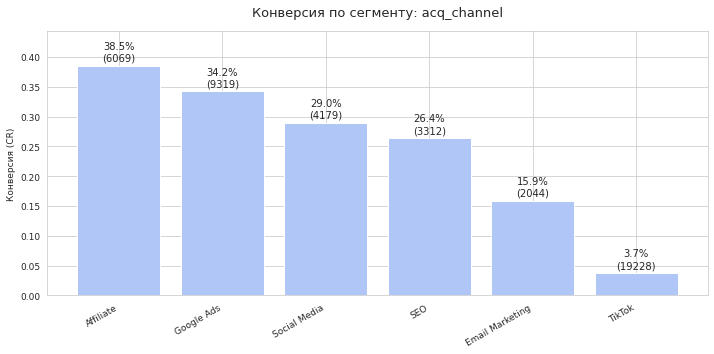

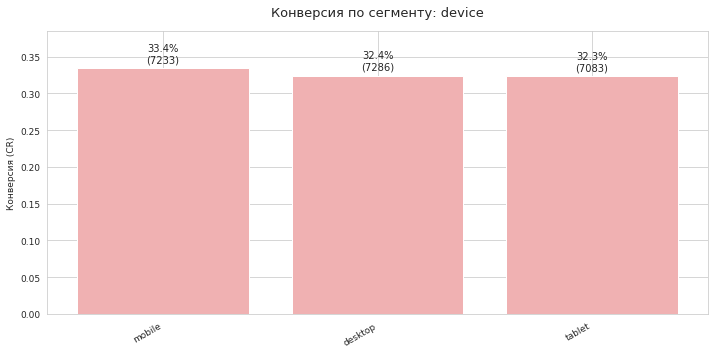

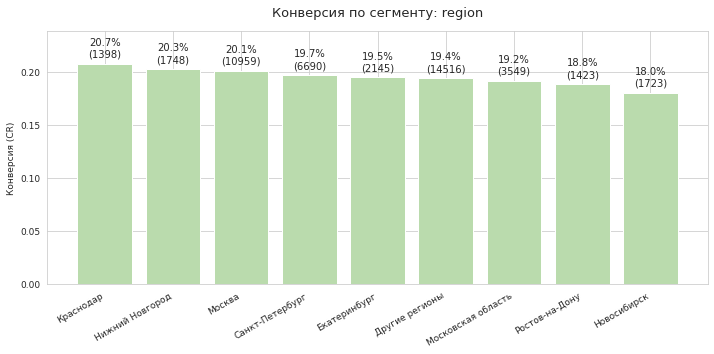

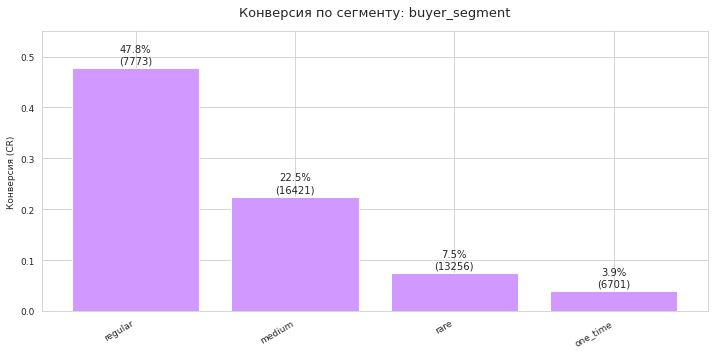

In [ ]:
# Сегментный анализ: поиск драйверов и барьеров конверсии

# Цель: выявить, какие группы пользователей конвертируются лучше/хуже, 
# чтобы сформировать гипотезы по оптимизации маркетинга и продукта

# 1. Обогащаем таблицу пользователей данными об устройствах
# Добавляем device из событий, чтобы анализировать конверсию по платформам
if 'device' not in users.columns:
    first_event = events_clean.drop_duplicates(subset='user_id')[['user_id', 'device']]
    users = users.merge(first_event, on='user_id', how='left')

# 2. Формируем флаг платящего пользователя 
# Пользователь считается платящим, если совершил хотя бы один заказ
payer_ids = set(orders_clean['user_id'])
users['is_payer'] = users['user_id'].isin(payer_ids)

# 3. Определяем срезы для сегментации
# Анализируем конверсию по каналам привлечения, устройствам, регионам и поведенческим сегментам
segments = ['acq_channel', 'device', 'region', 'buyer_segment']
# Цветовая палитра для визуального разделения сегментов на графиках
segment_colors = {'acq_channel': '#b0c6f7','device': '#f0b1b2', 'region': '#badbad', 'buyer_segment': '#d199ff'}



sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 9})

for seg in segments:
        
    # Агрегация: считаем общее число пользователей и платящих в каждом сегменте
    agg = (users.groupby(seg).agg(total_users=('user_id', 'size'), paying_users=('is_payer', 'sum')).reset_index())
    agg['cr'] = agg['paying_users'] / agg['total_users']
    
    # Фильтрация: исключаем мелкие группы (<50 пользователей) для статистической надёжности
    agg = agg[agg['total_users'] >= 50].sort_values('cr', ascending=False)
       
    # Отбор: показываем ТОП-10 по охвату для лучшей читаемости графиков
    agg_top = agg.nlargest(10, 'total_users').sort_values('cr', ascending=False)
    
    color = segment_colors.get(seg, '#4f46e5')
    
    # Визуализация: столбчатая диаграмма конверсии по значениям сегмента
    plt.figure(figsize=(10, 5))
    bars = plt.bar(agg_top[seg], agg_top['cr'], color=color)
    
    plt.ylabel('Конверсия (CR)')
    plt.title(f'Конверсия по сегменту: {seg}', fontsize=13, pad=15)
    plt.xticks(rotation=30, ha='right')
    
    # Аннотации: добавляем % конверсии и размер выборки для интерпретации
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.005,
            f'{height:.1%}\n({int(agg_top.iloc[i]["total_users"])})',
            ha='center', va='bottom', fontsize=10
        )
    
    plt.ylim(0, agg_top['cr'].max() * 1.15)
    plt.tight_layout()
    plt.show()

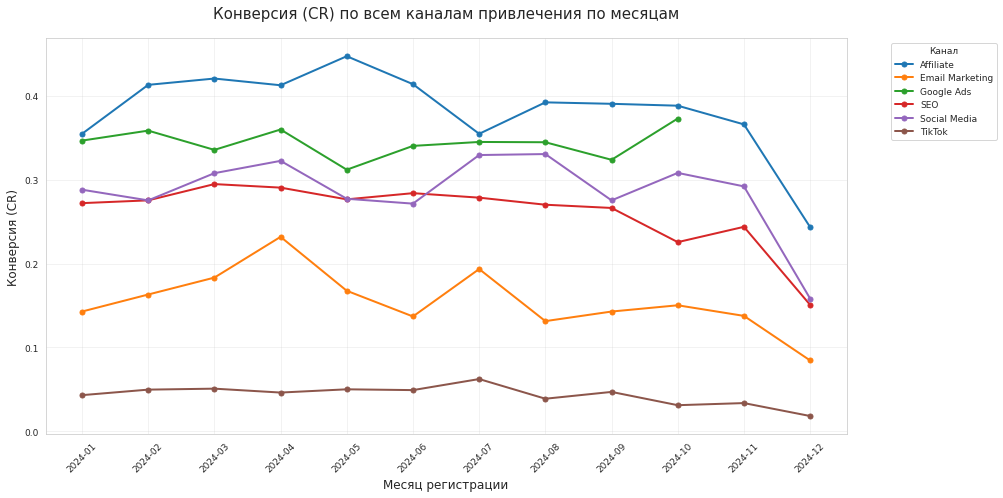

In [ ]:
# Динамика конверсии по каналам: оценка качества трафика во времени

# Цель: выявить, как меняется способность каналов привлекать платящих пользователей,
# и обнаружить ранние сигналы ухудшения качества трафика

# 1. Формируем флаг платящего пользователя для расчёта конверсии
# Пользователь считается платящим, если совершил хотя бы один заказ в 2024 году
payer_ids = set(orders_clean['user_id'])
users['is_payer'] = users['user_id'].isin(payer_ids)


# 2. Агрегируем данные по каналу и месяцу привлечения
# Считаем общее число пользователей и число платящих в каждой когорте (канал × месяц)
cr_by_channel_month = (users.groupby(['acq_channel', 'cohort_month']).agg(
        total_users=('user_id', 'size'),
        paying_users=('is_payer', 'sum')
    ).reset_index())

# Рассчитываем конверсию: доля платящих от общего числа привлечённых
cr_by_channel_month['cr'] = cr_by_channel_month['paying_users'] / cr_by_channel_month['total_users']

# 3. Фильтруем статистически ненадёжные группы
# Исключаем когорты с <50 пользователями — в них конверсия может быть искажена случайными колебаниями
cr_by_channel_month = cr_by_channel_month[cr_by_channel_month['total_users'] >= 50]

# 4. Визуализация: динамика CR по каналам во времени
# Позволяет увидеть, когда и в каких каналах начинается деградация качества трафика
plt.figure(figsize=(14, 7))

channels = cr_by_channel_month['acq_channel'].unique()

# Строим отдельную линию для каждого канала — так легче сравнивать тренды
for channel in channels:
    data = cr_by_channel_month[cr_by_channel_month['acq_channel'] == channel]
    plt.plot(data['cohort_month'], data['cr'], marker='o', label=channel, linewidth=2, markersize=5)

# Оформление: акцент на сравнении каналов, а не на абсолютных значениях
plt.title('Конверсия (CR) по всем каналам привлечения по месяцам', fontsize=15, pad=20)
plt.ylabel('Конверсия (CR)', fontsize=12)
plt.xlabel('Месяц регистрации', fontsize=12)
plt.legend(title='Канал', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Категориальный анализ: вклад товарных групп в выручку и спрос

# Агрегируем метрики по категориям:
# • orders — количество заказов как индикатор популярности категории
# • gmv — общий объём транзакций для оценки вклада в выручку
# • users — уникальные покупатели для оценки охвата аудитории
# • aov — средний чек категории для оценки платёжеспособности спроса
category_metrics = (orders_clean.groupby('category_name').agg(
        orders=('order_id', 'count'),
        gmv=('total_price_fixed', 'sum'),
        users=('user_id', 'nunique')
    ).reset_index())

# Рассчитываем средний чек (AOV) по категории:
# GMV / количество заказов = типичная стоимость покупки в этой группе товаров
category_metrics['aov'] = category_metrics['gmv'] / category_metrics['orders']
category_metrics

,category_name,orders,gmv,users,aov
0,Автотовары,1004,20145244.81,541,20064.984871
1,Аксессуары для гаджетов,1222,13549972.70,706,11088.357365
2,Бытовая техника,1001,43737963.22,529,43694.268951
3,Декор и освещение,1024,13691538.47,523,13370.643037
4,Детская одежда,1373,6182803.60,913,4503.134450
5,Детские игрушки,1103,8480428.91,538,7688.512158
6,Женская одежда,1155,13372299.03,624,11577.748078
7,Зоотовары,1362,7257176.51,865,5328.323429
8,Инструменты и садовый инвентарь,981,15896367.41,486,16204.248124
9,Книги и канцтовары,1287,3992504.33,723,3102.178967


       acq_channel  total_budget  total_users      cac    cr    roi
0        Affiliate     974810.41         6069   160.62  0.39  33.64
1  Email Marketing      88680.74         2044    43.39  0.16  51.40
2       Google Ads    4811932.30         9319   516.36  0.34   9.29
3              SEO     176297.57         3312    53.23  0.26  69.52
4     Social Media     557501.92         4179   133.41  0.29  30.46
5           TikTok   21668422.31        19228  1126.92  0.04   0.47


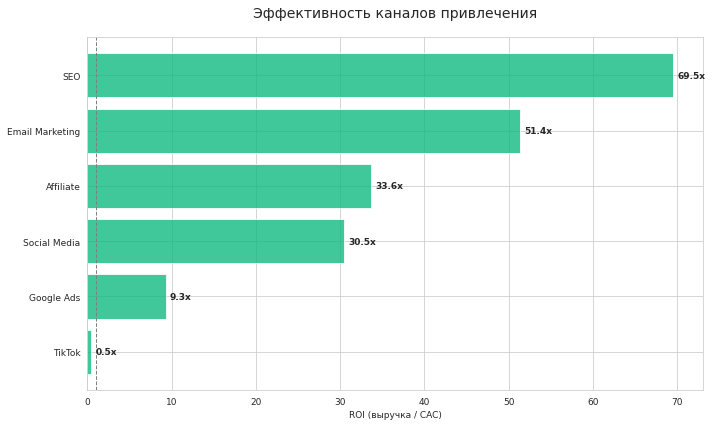

In [ ]:
# Анализ эффективности каналов: CAC, CR, ROI

# Цель: сравнить каналы привлечения по рентабельности инвестиций,
# чтобы выявить прибыльные источники и точки для оптимизации бюджета

# 1. Приводим временные метки к единому формату для корректного соединения
# Преобразуем spend_month и cohort_month в период 'YYYY-MM' для точного сопоставления
# Делим бюджет на 1000 для удобства визуализации (тысячи рублей вместо единиц)
campaigns_2024['budget'] = campaigns_2024['budget'] / 1000
campaigns_2024['spend_month'] = pd.to_datetime(campaigns_2024['spend_month']).dt.to_period('M').astype(str)
users['cohort_month'] = pd.to_datetime(users['cohort_month']).dt.to_period('M').astype(str)

# 2. Агрегируем маркетинговые затраты по каналу и месяцу
# Суммируем бюджет, чтобы сопоставить затраты с привлечёнными пользователями
monthly_budget_by_channel = (campaigns_2024
    .groupby(['acq_channel', 'spend_month'])['budget']
    .sum()
    .reset_index())

# 3. Присоединяем затраты к пользователям по каналу и месяцу привлечения
# Это позволяет рассчитать стоимость привлечения (CAC) для каждой группы
users_with_budget = pd.merge(users,monthly_budget_by_channel,
    left_on=['acq_channel', 'cohort_month'],
    right_on=['acq_channel', 'spend_month'],
    how='left')

# 4. Расчёт CAC по каналам
# CAC = суммарные затраты на канал / число привлечённых пользователей
cac_by_channel = (users_with_budget.groupby('acq_channel').agg(
        total_budget=('budget', 'sum'),
        total_users=('user_id', 'size')).reset_index()
)
cac_by_channel['cac'] = cac_by_channel['total_budget'] / cac_by_channel['total_users']

# 5. Расчёт CR (Conversion Rate) по каналам
# CR = доля пользователей, совершивших хотя бы одну покупку
cr_by_channel = users.groupby('acq_channel').agg(cr=('is_payer', 'mean')).reset_index()

# 6. Объединяем метрики для комплексной оценки
channel_metrics = pd.merge(cac_by_channel, cr_by_channel, on='acq_channel')

# 7. Расчёт ROI (Return on Investment) по каналам
# ROI = (CR × AOV) / CAC, где AOV — средний чек, усреднённый по всем заказам
# Интерпретация: ROI > 1 = канал прибыльный, ROI < 1 = канал убыточный
AOV = orders_clean['total_price_fixed'].sum() / len(orders_clean)
channel_metrics['roi'] = (channel_metrics['cr'] * AOV) / channel_metrics['cac']

# Вывод сводной таблицы для быстрой проверки
print(channel_metrics[['acq_channel', 'total_budget', 'total_users', 'cac', 'cr', 'roi']].round(2))

# 8. Визуализация: сравнение каналов по ROI
# Сортируем по возрастанию, чтобы сразу видеть аутсайдеров и лидеров
plot_data = channel_metrics.copy()
plot_data = plot_data.sort_values('roi', ascending=True)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Горизонтальная гистограмма: каналы по оси Y, ROI по оси X
colors = ['#10b981']
bars = ax1.barh(plot_data['acq_channel'], plot_data['roi'], color=colors, alpha=0.8)

# Оформление: акцент на пороговом значении (ROI = 1 — точка безубыточности)
ax1.set_xlabel('ROI (выручка / CAC)')
ax1.set_title('Эффективность каналов привлечения', fontsize=14, pad=20)
ax1.axvline(x=1, color='gray', linestyle='--', linewidth=1)

# Подписи значений на барах для интерпретации
for bar, roi in zip(bars, plot_data['roi']):
    ax1.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{roi:.1f}x',
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

CR TikTok по устройству:
 device
desktop    0.072842
mobile     0.073595
tablet     0.065089
Name: is_payer, dtype: float64

CR TikTok по региону (ТОП-5):
 region
Краснодар          0.047863
Нижний Новгород    0.043364
Другие регионы     0.038333
Новосибирск        0.036991
Москва             0.036975
Name: is_payer, dtype: float64


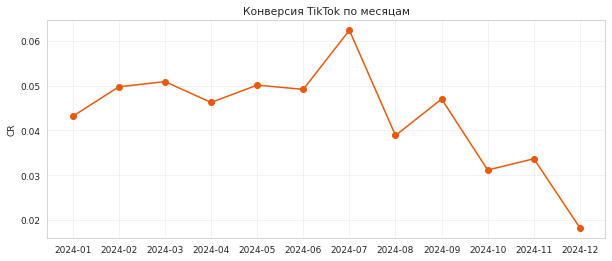

In [ ]:
# Детальный анализ канала TikTok: поиск причин низкой конверсии

# Цель: понять, связана ли низкая CR TikTok с техническими факторами 
# (устройство, регион) или с качеством самого трафика

# 1. Фильтруем данные по каналу TikTok для углублённого разбора
tiktok_users = users[users['acq_channel'] == 'TikTok']

# 2. Сегментация по техническим параметрам: устройство и регион
# Проверяем гипотезу: может, низкая CR характерна только для мобильных или отдельных регионов?
tiktok_cr_by_device = tiktok_users.groupby('device')['is_payer'].mean()
tiktok_cr_by_region = tiktok_users.groupby('region')['is_payer'].mean()

# Выводим топ-5 регионов по конверсии — если даже в лучших регионах CR низкая, 
# проблема не в географии, а в качестве аудитории
print("CR TikTok по устройству:\n", tiktok_cr_by_device)
print("\nCR TikTok по региону (ТОП-5):\n", tiktok_cr_by_region.nlargest(5))

# 3. Динамика конверсии TikTok во времени
# Проверяем, деградирует ли качество трафика со временем или проблема системная
tiktok_monthly = (
    users[users['acq_channel'] == 'TikTok']
    .groupby('cohort_month')
    .agg(total=('user_id', 'size'), payers=('is_payer', 'sum'))
    .reset_index()
)
tiktok_monthly['cr'] = tiktok_monthly['payers'] / tiktok_monthly['total']

# Визуализация: линейный график для отслеживания тренда
plt.figure(figsize=(10, 4))
plt.plot(tiktok_monthly['cohort_month'], tiktok_monthly['cr'], marker='o', color='#ea580c')
plt.title('Конверсия TikTok по месяцам')
plt.ylabel('CR')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Анализ воронки покупок: поиск узких мест в пути пользователя

# Цель: выявить, на каком этапе пользователи чаще всего отваливаются,
# чтобы сформировать гипотезы по оптимизации UX и повышению конверсии

# 1. Определяем ключевые этапы классической e-commerce воронки
# От первого интереса к товару до завершения оформления заказа
funnel_steps = [
    'product_view',
    'add_to_cart',
    'checkout_start',
    'checkout_complete'
]

funnel_data = []

# 2. Считаем уникальных пользователей на каждом этапе воронки 
# Используем nunique(), чтобы один пользователь не учитывался многократно
# Это даёт корректную картину охвата, а не количества событий
for step in funnel_steps:
    user_count = events_clean[events_clean['event_type'] == step]['user_id'].nunique()
    funnel_data.append([step, user_count])

# 3. Формируем таблицу для анализа конверсии между этапами
funnel_df = pd.DataFrame(funnel_data, columns=['step', 'users'])

# 4. Рассчитываем две метрики конверсии для разных вопросов бизнеса

# conversion_from_first_%: какая доля от начавших просмотр дошла до каждого этапа
# отвечает на вопрос "насколько эффективно мы удерживаем интерес?"

# conversion_from_previous_%: какая доля перешла с предыдущего шага на текущий
# отвечает на вопрос "где самое узкое место в воронке?"
funnel_df['conversion_from_first_%'] = (funnel_df['users'] / funnel_df['users'].iloc[0] * 100).round(1)
funnel_df['conversion_from_previous_%'] = (funnel_df['users'] / funnel_df['users'].shift(1) * 100).round(1)

# Выводим итоговую таблицу: по ней сразу видно, где происходят основные потери
display(funnel_df)

,step,users,conversion_from_first_%,conversion_from_previous_%
0,product_view,21533,100.0,NaN
1,add_to_cart,19887,92.4,92.4
2,checkout_start,16292,75.7,81.9
3,checkout_complete,13484,62.6,82.8


In [ ]:
# Визуализация воронки: два ракурса для разных бизнес-вопросов

# Цель: наглядно показать, где происходят основные потери пользователей,
# используя два типа конверсии для полной картины

# 1. Подготовка данных: считаем охват на каждом этапе воронки
# Используем nunique(), чтобы каждый пользователь учитывался только один раз на этапе
steps = ['product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']
counts = [
    events_clean[events_clean['event_type'] == step]['user_id'].nunique()
    for step in steps
]

# 2. График 1: конверсия от входа в воронку (product_view) 
# Показывает, какая доля от всех, кто начал смотреть товары, дошла до каждого этапа,
# насколько эффективно удерживается интерес от первого касания
conv_from_first = [c / counts[0] * 100 for c in counts]
df1 = pd.DataFrame({'step': steps, 'conversion': conv_from_first})

fig1 = px.funnel(
    df1,
    x='conversion',
    y='step',
    title='Конверсия от первого шага (%)',
    labels={'conversion': 'Конверсия, %'}
)

# 3. Подготовка данных: конверсия между соседними этапами
# Показывает, какая доля перешла с одного шага на следующий, самое узкое место, где мы теряем больше всего
fig1.update_yaxes(autorange="reversed")
fig1.update_traces(texttemplate='%{x:.1f}%', textposition='inside')
fig1.show(renderer="notebook")

transitions = [
    'product_view → add_to_cart',
    'add_to_cart → checkout_start',
    'checkout_start → checkout_complete'
]

conv_from_prev = [
    counts[1] / counts[0] * 100, 
    counts[2] / counts[1] * 100,
    counts[3] / counts[2] * 100  
]

df2 = pd.DataFrame({'transition': transitions, 'conversion': conv_from_prev})

# 4. График 2: конверсия между этапами (step-by-step)
# Акцент на переходах: помогает точно локализовать проблемный этап для оптимизации
fig2 = px.funnel(
    df2,
    x='conversion',
    y='transition',
    title='Конверсия от предыдущего шага (%)',
    labels={'conversion': 'Конверсия, %', 'transition': 'Переход на этап'}
)
fig2.update_traces(marker_color='#f59e0b')
fig2.update_yaxes(autorange="reversed")
fig2.update_traces(texttemplate='%{x:.1f}%', textposition='inside')
fig2.show()


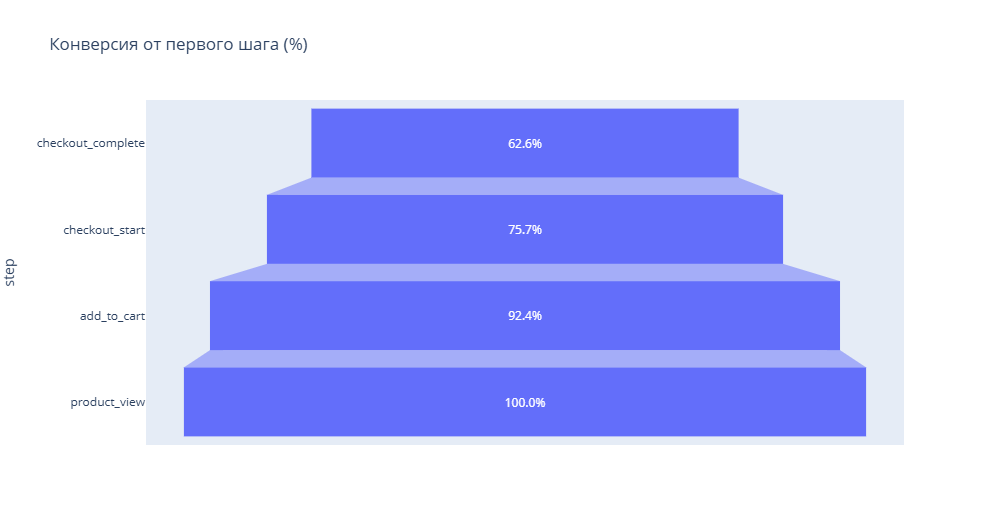

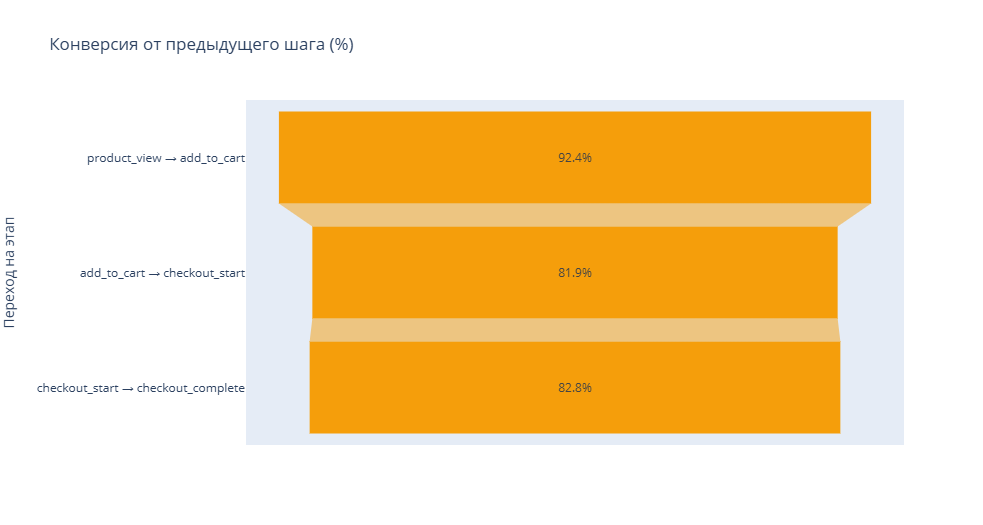

In [ ]:
# Сравнительный анализ воронок: поиск изменений в поведении 
# пользователей между первым и вторым полугодием

# Цель: выявить, на каких этапах воронки произошли изменения 
# в конверсии, чтобы локализовать причину спада монетизации

# 1. Сегментируем данные по полугодиям для сравнения динамики
# H1 = январь–июнь (период роста), H2 = июль–декабрь (период спада)
# Это позволяет изолировать влияние сезонности от структурных изменений
events_clean['half'] = events_clean['event_date'].dt.month.map(lambda m: 'H1' if m <= 6 else 'H2')


# 2. Подготовка данных для сравнительной воронки 
# Анализируем те же четыре ключевых этапа, что и в базовом анализе
steps = ['product_view', 'add_to_cart', 'checkout_start', 'checkout_complete']

funnel_data = []

# 3. Считаем уникальных пользователей на каждом этапе для каждого полугодия
# Вложенный цикл: сначала по полугодиям, затем по этапам воронки
# Это даёт матрицу для сравнения охвата между периодами
for half in ['H1', 'H2']:
    for step in steps:
        count = events_clean[
            (events_clean['event_type'] == step) & 
            (events_clean['half'] == half)
        ]['user_id'].nunique()
        funnel_data.append({'step': step, 'users': count, 'half': half})

funnel_df = pd.DataFrame(funnel_data)

# 4. Визуализация: сравнительная воронка с цветовой кодировкой по полугодиям 
# Позволяет мгновенно увидеть, где произошли наибольшие изменения в конверсии
fig = px.funnel(
    funnel_df,
    x='users',
    y='step',
    color='half',
    title='Сравнение воронок по полугодиям',
    labels={'users': 'Уникальные пользователи', 'step': 'Этап воронки'}
)

# Фиксируем порядок этапов воронки: от широкого входа к узкому выходу
fig.update_yaxes(categoryorder='array', categoryarray=steps)

fig.show()

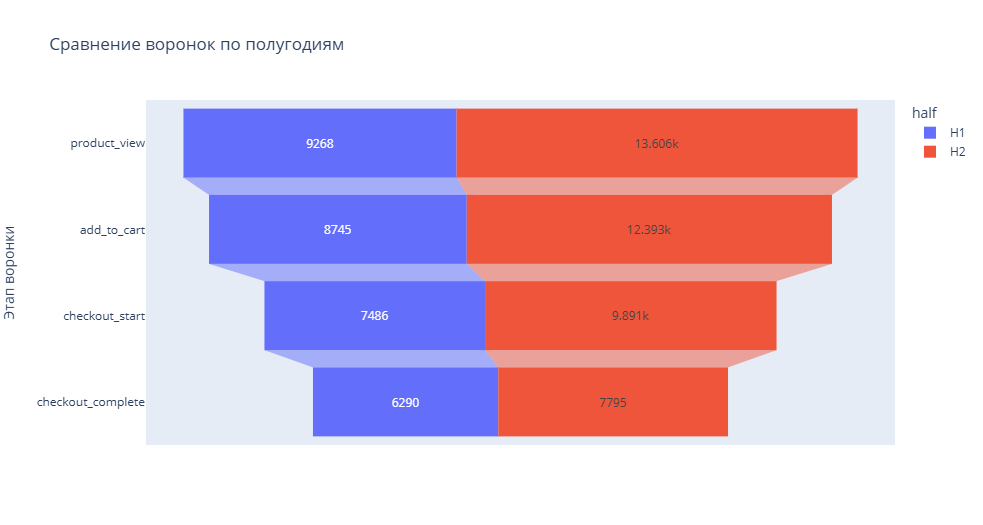

### Аналитическая записка: инсайты и точки роста

---

#### Ключевые наблюдения

**Лучшие сегменты**

| Срез | Лидеры | Метрики | Почему важно |
|------|--------|---------|--------------|
| **Каналы** | SEO, Affiliate | CR: 26–39%, ROI: 33–70× | Недофинансированы (<20% бюджета), но стабильно прибыльны |
| **Поведение** | `regular` | CR = 47,8% | Ядро лояльных клиентов с высоким LTV |
| **Категории** | Мебель, Бытовая техника, Украшения | AOV: 33–73 тыс. ₽ | Лидеры по GMV и маржинальности |

**Худшие сегменты**

| Срез | Проблемные зоны | Метрики | Интерпретация |
|------|----------------|---------|---------------|
| **Канал** | TikTok | Доля: 62% в H2, CR: 1,8–4,9%, ROI: 0,47× | Трафик без покупательской способности: каждый рубль возвращает 47 копеек |
| **Поведение** | `one_time` (CR = 3,9%), `rare` (CR = 7,5%) | Низкое удержание | Преобладают среди пользователей TikTok, почти не возвращаются |
| **Время** | Декабрь | Резкое падение CR во всех каналах | Сезонный спад + усиление проблемы качества трафика |

**Этапы потери в воронке**

| Переход | Конверсия (H2) | Динамика | Комментарий |
|---------|---------------|----------|-------------|
| `product_view` → `add_to_cart` | 91% | Стабильно | Пользователи успешно находят и добавляют товары |
| `add_to_cart` → `checkout_start` | 82% | Небольшое снижение | Интерес есть, но часть отсеивается перед оплатой |
| `checkout_start` → `checkout_complete` | **57,3%** | **↓ с 72,7%** | Главное узкое место: потеря ~15 п.п. во втором полугодии |

Особенно критично для категорий с **AOV > 30 000 ₽** (мебель, техника, украшения), где важны прозрачность цены, доверие и условия доставки.

---

#### Точки роста и приоритеты

**Что масштабировать**
1.  **SEO и Affiliate** — каналы с рекордным ROI (33–70×) и низким CAC. Сейчас получают <20% бюджета — есть резерв для роста без увеличения затрат.
2.  **Сегмент `medium`** — 37% пользователей с CR = 22,5%. Имеют высокий потенциал перехода в `regular` при минимальных инвестициях в персонализацию.

**Куда инвестировать ресурсы**

| Направление | Конкретные действия | Ожидаемый эффект |
|-------------|--------------------|------------------|
| **Перераспределение бюджета** | Сократить долю TikTok, направить средства в SEO, Affiliate, Google Ads | Рост общего ROI без увеличения маркетинговых затрат |
| **Оптимизация checkout** | Прозрачный блок «Итого к оплате», упрощение формы для категорий с AOV > 30 000 ₽ | Рост конверсии на этапе оформления на 10–12 п.п. |
| **Работа с аудиторией** | • Реактивация `medium` через персонализированные рекомендации и бонусы <br> • Онбординг для TikTok-аудитории: акцент на гарантии, отзывы, бесплатную доставку | • Рост перехода в `regular` на 15–20% <br> • Увеличение первой покупки в TikTok на 30–50% |

---

#### Обоснованные гипотезы

**Гипотеза 1: Перераспределение бюджета**

`Если перераспределить 50–60% маркетингового бюджета из TikTok в каналы SEO и Affiliate,  
 то общий ROI вырастет с 1,2× до 2,0×+,  
 потому что TikTok даёт 62% трафика при ROI = 0,47×, а SEO (ROI = 69,5×) и Affiliate (ROI = 33,6×) недополучают инвестиции при стабильной конверсии >33%.`

**Гипотеза 2: Оптимизация checkout для дорогих категорий**

`Если внедрить прозрачный блок «Итого к оплате» (цена + доставка + гарантия) для категорий с AOV > 30 000 ₽,  
 то конверсия на этапе "checkout_start → checkout_complete" вырастет на 10–12 п.п.,  
 потому что пользователи из массовых каналов особенно чувствительны к скрытым расходам при крупных покупках.`

**Гипотеза 3: Рост лояльности через CRM**

`Если запустить email-кампанию с персонализированными рекомендациями и бонусами для сегмента "medium",  
 то доля перехода в "regular" увеличится на 15–20%,  
 потому что эта группа уже проявляет интерес (CR = 22,5%), но не достигает лояльности без дополнительного стимула.`

**Гипотеза 4: Реанимация TikTok через усиленный онбординг** *(тестовая)*

`Если для новых пользователей из TikTok запустить A/B-тест: ` 

 ` - контроль: стандартный UX,`

  `- тест: онбординг с акцентом на гарантии, отзывы и бесплатную доставку,  `
  
 `то конверсия в тестовой группе вырастет на 30–50% (с ~4% до 5–6%),  
 потому что 62% пользователей TikTok попадают в сегменты "one_time"/"rare" и не видят ценности платформы на ранних этапах.
 Условие: если эффект не подтвердится за 4 недели — перераспределить бюджет в SEO и Affiliate.`

---

**Резюмируем**:  
> Главная проблема — не в продукте, а в качестве трафика. Восстановление роста возможно не за счёт увеличения бюджета, а за счёт:  
> 1. Перераспределения инвестиций в доказанно прибыльные каналы,  
> 2. Точечной оптимизации узких мест воронки,  
> 3. Сегментированной работы с аудиторией для повышения лояльности.

### Выводы по этапу 4: Анализ сегментов и гипотезы

---

#### Ключевые инсайты

**1. Главная проблема — не в продукте, а в качестве трафика**
- Во второй половине 2024 года доля пользователей из **TikTok** выросла с **15% до 62%**, при этом их конверсия осталась крайне низкой (**CR = 1,8–4,9%**), а **ROI канала = 0,47×** (убыток).
- Это основной драйвер падения общей конверсии с **1,80% до 1,48%** и общей монетизации.

**2. Воронка теряет на этапе checkout, особенно в дорогих категориях**
- Пользователи успешно находят и добавляют товары в корзину: конверсия `product_view → add_to_cart = 91%`.
- Но на этапе оформления заказа конверсия падает **с 72,7% до 57,3%**.
- Особенно критично для категорий с **AOV > 30 000 ₽** (мебель, техника, украшения), где важны прозрачность цены, доверие и условия доставки.

**3. Высокомаржинальные каналы недоиспользуются**
- Каналы **SEO** (ROI = 69,5×) и **Affiliate** (ROI = 33,6×) демонстрируют стабильно высокую конверсию (>35%) и низкий CAC.
- При этом они получают **менее 20% маркетингового бюджета** — есть резерв для роста без увеличения затрат.

**4. Сегмент `medium` — точка роста лояльности**
- **37%** пользователей относятся к сегменту `medium` (**CR = 22,5%**).
- Небольшой стимул может перевести их в ядро лояльных клиентов (`regular`, **CR = 47,8%**).

**5. Регионы и устройства не являются источником проблемы**
- Конверсия по регионам стабильна (**18–21%**).
- Разница между **mobile** (33,4%) и **desktop** (32,4%) незначительна — проблема не в технической платформе.

---

#### Обоснованные гипотезы

| № | Гипотеза | Ожидаемый эффект | Обоснование |
|---|----------|-----------------|-------------|
| **1** | Перераспределить **50–60%** бюджета из TikTok в **SEO** и **Affiliate** | Рост общего ROI с **1,2× до 2,0×+** | TikTok даёт 62% трафика при ROI = 0,47×, а SEO/Affiliate недополучают инвестиции при ROI >30× |
| **2** | Внедрить блок «Итого к оплате» для категорий с **AOV > 30 000 ₽** | Рост конверсии на этапе checkout на **10–12 п.п.** | Пользователи чувствительны к скрытым расходам при крупных покупках; текущая потеря — 15 п.п. |
| **3** | Запустить email-кампанию с бонусами для сегмента `medium` | Доля перехода в `regular` вырастет на **15–20%** | Группа уже проявляет интерес (CR = 22,5%), но не достигает лояльности без стимула |
| **4** | A/B-тест онбординга для TikTok-аудитории (гарантии, отзывы, доставка) | Рост конверсии в тестовой группе на **30–50%** (с ~4% до 5–6%) | 62% пользователей TikTok — `one_time`/`rare`; раннее формирование доверия может повысить склонность к покупке |

> **Условие для гипотезы 4**: если эффект не подтвердится за 4 недели — перераспределить бюджет из TikTok в SEO и Affiliate.

---

#### Резюме для принятия решений

| Проблема | Решение | Приоритет |
|----------|---------|-----------|
| Низкое качество трафика из TikTok | Сократить долю канала, перенаправить бюджет в SEO/Affiliate | Высокий |
| Потери на этапе checkout для дорогих категорий | Оптимизировать форму оформления, добавить прозрачность цены | Средний |
| Низкая лояльность сегмента `medium` | Персонализированные коммуникации и бонусы за повторную покупку | Средний |
| Отсутствие доверия у новой аудитории TikTok | Тестовый онбординг с акцентом на гарантии и социальное доказательство | Низкий (тест) |

> **Итог**: восстановление роста возможно не за счёт увеличения бюджета, а за счёт **перераспределения инвестиций**, **точечной оптимизации воронки** и **сегментированной работы с аудиторией**.

### 5. Эксперимент: бонус на первую покупку для пользователей TikTok

**Контекст запуска**
На основе инсайтов этапа 4 команда продукта приняла решение протестировать финансовую стимуляцию как способ повышения конверсии среди пользователей, привлечённых через канал TikTok. Ситуация требовала быстрого решения: выручка снижалась, а доля низкокачественного трафика из TikTok достигла 62%.

**Роль аналитика**
Дизайн эксперимента был подготовлен коллегой, моя задача — провести A/B-тест, проанализировать результаты и сформулировать рекомендации для масштабирования (или остановки) инициативы.

---

#### Дизайн эксперимента

| Параметр | Значение |
|----------|----------|
| **Тип** | Сплит-роллинг (rolling split) |
| **Целевая аудитория** | Новые пользователи, привлечённые через канал TikTok |
| **Гипотеза** | Предоставление бонуса на первую покупку увеличит конверсию в покупку среди пользователей TikTok |
| **Группы** | • **Control (A)**: стандартный UX, без бонуса <br> • **Treatment (B)**: бонус на первую покупку |
| **Распределение** | Равномерное, по дате регистрации пользователя |
| **Длительность** | 3 недели (фиксированный горизонт) |

---

#### Метрики оценки

**Основная метрика**
- **Конверсия в первую покупку** — доля пользователей, зарегистрировавшихся через TikTok и совершивших хотя бы один заказ.
- *Критерий успеха*: статистически значимый рост конверсии в тестовой группе (p < 0.05, односторонний тест).

**Вспомогательные метрики**
| Метрика | Формула | Зачем считаем |
|---------|---------|---------------|
| **ARPU** | Выручка / все пользователи TikTok | Оцениваем влияние бонуса на общую монетизацию канала |
| **ARPPU** | Выручка / платящие пользователи TikTok | Понимаем, меняет ли бонус поведение тех, кто уже купил |
| **AOV** | GMV / количество заказов | Проверяем, не стимулирует ли бонус только мелкие покупки |

**Барьерная метрика**
- **Общая выручка от пользователей TikTok** — гарантирует, что рост конверсии не достигается за счёт критического снижения среднего чека.

---

#### Данные и ограничения

**Источники данных**
Анализ проведён на основе четырёх датасетов, содержащих события, заказы и профили пользователей в период эксперимента:
- `users_AB`, `events_AB`, `orders_AB` — поведенческие и транзакционные данные
- `AB_split_users` — принадлежность пользователей к контрольной или тестовой группе

> **Ограничение метода**: Из-за срочности задачи эксперимент запущен без предварительного расчёта статистической мощности и MDE. Это повышает риск ошибок II рода (не обнаружить существующий эффект), но допустимо в условиях быстрого тестирования гипотез. Результаты интерпретируются с учётом этого ограничения.

In [ ]:
# Загрузка данных для анализа A/B-теста: бонус на первую покупку

# Контекст: оцениваем влияние финансовой стимуляции на конверсию 
# пользователей, привлечённых через канал TikTok

# 1. Источники данных: поведенческие и транзакционные логи
# Данные охватывают 3-недельный период эксперимента и содержат только пользователей из канала TikTok (контроль + тест)
# Пути к файлам маскированы для безопасности репозитория
EVENTS_AB_PATH = '{путь}pa_marketplace_events_AB.csv'
ORDERS_AB_PATH = '{путь}pa_marketplace_orders_AB.csv'
USERS_AB_PATH = '{путь}pa_marketplace_users_AB.csv'

events_AB = pd.read_csv(EVENTS_AB_PATH)
orders_AB = pd.read_csv(ORDERS_AB_PATH)
users_AB = pd.read_csv(USERS_AB_PATH)

# 2. Таблица распределения по группам эксперимента
# Содержит mapping user_id → group (control/treatment)
# Критична для корректного разделения выборки при расчёте метрик
SPLIT_PATH = '{путь}pa_marketplace_AB_split_users.csv'
AB_split_users = pd.read_csv(SPLIT_PATH)

In [ ]:
# Диагностика качества данных перед анализом A/B-теста

# Цель: убедиться, что данные целостны и не содержат артефактов,
# которые могут исказить оценку эффекта эксперимента
for name, df in [("users_AB", users_AB), ("events_AB", events_AB), ("orders_AB", orders_AB), ("AB_split_users", AB_split_users)]:
    print(f"\n{name.upper()}")
    print(df.info())
    print("\nПропуски:")
    print(df.isnull().sum())
    print("\nДубликаты строк:", df.duplicated().sum())
    print("\nПервые строки:")
    display(df.head())


USERS_AB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22196 entries, 0 to 22195
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            22196 non-null  int64 
 1   registration_date  22196 non-null  object
 2   age                22196 non-null  int64 
 3   gender             22196 non-null  object
 4   region             22196 non-null  object
 5   acq_channel        22196 non-null  object
 6   buyer_segment      22196 non-null  object
 7   cohort_week        22196 non-null  object
 8   cohort_month       22196 non-null  object
dtypes: int64(2), object(7)
memory usage: 1.5+ MB
None

Пропуски:
user_id              0
registration_date    0
age                  0
gender               0
region               0
acq_channel          0
buyer_segment        0
cohort_week          0
cohort_month         0
dtype: int64

Дубликаты строк: 0

Первые строки:


,user_id,registration_date,age,gender,region,acq_channel,buyer_segment,cohort_week,cohort_month
0,18,2024-01-01 05:26:00,49,M,Екатеринбург,TikTok,one_time,2024-01-01,2024-01-01
1,22,2024-01-01 17:13:00,50,M,Санкт-Петербург,TikTok,one_time,2024-01-01,2024-01-01
2,26,2024-01-01 21:15:00,60,F,Москва,TikTok,rare,2024-01-01,2024-01-01
3,33,2024-01-01 14:43:00,31,M,Екатеринбург,TikTok,rare,2024-01-01,2024-01-01
4,39,2024-01-01 01:13:00,44,M,Санкт-Петербург,TikTok,rare,2024-01-01,2024-01-01



EVENTS_AB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 831231 entries, 0 to 831230
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   event_id      831231 non-null  int64 
 1   user_id       831231 non-null  int64 
 2   event_date    831231 non-null  object
 3   event_type    831231 non-null  object
 4   os            831231 non-null  object
 5   device        831231 non-null  object
 6   product_name  409054 non-null  object
 7   event_week    831231 non-null  object
 8   event_month   831231 non-null  object
dtypes: int64(2), object(7)
memory usage: 57.1+ MB
None

Пропуски:
event_id             0
user_id              0
event_date           0
event_type           0
os                   0
device               0
product_name    422177
event_week           0
event_month          0
dtype: int64

Дубликаты строк: 0

Первые строки:


,event_id,user_id,event_date,event_type,os,device,product_name,event_week,event_month
0,3132,100,2024-01-01 15:23:56,page_view,iOS,mobile,NaN,2024-01-01,2024-01-01
1,3133,100,2024-01-01 15:24:01,product_view,iOS,mobile,Шорты для тренировок,2024-01-01,2024-01-01
2,3134,100,2024-01-01 15:24:10,product_click,iOS,mobile,Куртка детская,2024-01-01,2024-01-01
3,3135,100,2024-01-01 15:25:10,add_to_cart,iOS,mobile,Балетки классические,2024-01-01,2024-01-01
4,3136,100,2024-01-01 15:25:46,checkout_start,iOS,mobile,NaN,2024-01-01,2024-01-01



ORDERS_AB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33280 entries, 0 to 33279
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       33280 non-null  int64  
 1   user_id        33280 non-null  int64  
 2   order_date     33280 non-null  object 
 3   product_name   33280 non-null  object 
 4   quantity       33280 non-null  int64  
 5   unit_price     33280 non-null  float64
 6   total_price    33280 non-null  float64
 7   category_name  33280 non-null  object 
 8   order_week     33280 non-null  object 
 9   order_month    33280 non-null  object 
dtypes: float64(2), int64(3), object(5)
memory usage: 2.5+ MB
None

Пропуски:
order_id         0
user_id          0
order_date       0
product_name     0
quantity         0
unit_price       0
total_price      0
category_name    0
order_week       0
order_month      0
dtype: int64

Дубликаты строк: 0

Первые строки:


,order_id,user_id,order_date,product_name,quantity,unit_price,total_price,category_name,order_week,order_month
0,1,3,2024-01-19 01:52:52.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
1,2,3,2024-01-19 01:52:52.000,Молоток слесарный,1,11340.38,11340.38,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
2,3,3,2024-01-19 01:52:52.000,Секатор садовый,2,10892.09,21784.18,Инструменты и садовый инвентарь,2024-01-15,2024-01-01
3,4,3,2024-01-25 13:59:38.000,Шуруповерт,2,5539.13,11078.26,Инструменты и садовый инвентарь,2024-01-22,2024-01-01
4,5,3,2024-01-25 13:59:38.000,Чай черный,1,2099.59,2099.59,Продукты питания,2024-01-22,2024-01-01



AB_SPLIT_USERS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2968 entries, 0 to 2967
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  2968 non-null   int64 
 1   group    2968 non-null   object
dtypes: int64(1), object(1)
memory usage: 46.5+ KB
None

Пропуски:
user_id    0
group      0
dtype: int64

Дубликаты строк: 0

Первые строки:


,user_id,group
0,44965,control
1,44967,control
2,44968,control
3,44969,treatment
4,44970,control


In [ ]:
# Предобработка данных для A/B-теста: фокус на 21-дневном горизонте

# Цель: подготовить выборку для оценки эффекта бонуса на первую покупку
# в рамках фиксированного окна наблюдения (период действия стимула)

# 1. Приводим даты регистрации и заказов к формату datetime — это необходимо
# для вычисления временных интервалов и фильтрации по горизонту анализа
users_AB['registration_date'] = pd.to_datetime(users_AB['registration_date'])
orders_AB['order_date'] = pd.to_datetime(orders_AB['order_date'])

# 2. Ограничение выборки периодом действия бонуса (21 день)
# Связываем заказы с датами регистрации, чтобы отфильтровать только те покупки,
# которые попали в окно наблюдения эксперимента
orders_with_reg = orders_AB.merge(users_AB[['user_id', 'registration_date']], on='user_id')
orders_with_reg['days_to_order'] = (orders_with_reg['order_date'] - orders_with_reg['registration_date']).dt.days
orders_valid = orders_with_reg[orders_with_reg['days_to_order'] <= 21]

# 3. Расчёт выручки в рамках модели монетизации маркетплейса
# Комиссия платформы = 5% от total_price; агрегируем доход по пользователям
# для последующего сравнения между группами эксперимента
orders_valid['revenue'] = orders_valid['total_price'] * 0.05
user_revenue_21d = orders_valid.groupby('user_id')['revenue'].sum().reset_index()
user_revenue_21d.rename(columns={'revenue': 'total_revenue'}, inplace=True)

# 4. Формируем флаг платящего пользователя в горизонте 21 дня
# Пользователь считается конвертированным, если совершил хотя бы один заказ
# в течение трёх недель после регистрации — это соответствует основной метрике теста
payers_21d = set(orders_valid['user_id'])

# Создаём отдельный DataFrame с флагом для удобного присоединения к основной выборке
user_payer_flag = pd.DataFrame({
    'user_id': users_AB['user_id'],
    'is_payer_21d': users_AB['user_id'].isin(payers_21d)
})

# 5. Собираем финальную таблицу для анализа по группам
# Объединяем: распределение по группам + флаг платящего + канал привлечения + выручка
# Заполняем пропуски в revenue нулями для пользователей без заказов
exp_users = AB_split_users.merge(user_payer_flag, on='user_id', how='left').merge(users_AB[['user_id', 'acq_channel']],
    on='user_id', how='left').merge(user_revenue_21d, on='user_id', how='left')

exp_users['total_revenue'] = exp_users['total_revenue'].fillna(0)
exp_users.rename(columns={'is_payer_21d': 'is_payer'}, inplace=True)

# Быстрый просмотр: убеждаемся, что данные собрались корректно
display(exp_users.head())

# 6. Агрегация базовых метрик по экспериментальным группам
# Считаем размер выборки, число конверсий и суммарную выручку для контроля баланса
results = exp_users.groupby('group').agg(
    users=('user_id', 'count'),
    purchasers=('is_payer', 'sum'),
    revenue=('total_revenue', 'sum')
).reset_index()

# Вывод барьерной метрики: общая выручка от TikTok за 21 день
# Помогает быстро оценить, не «сломалась» ли монетизация в одной из групп
print("\nБарьерная метрика - Общая выручка от TikTok за 21 день:")
display(results[['group', 'revenue']].rename(columns={'revenue': 'total_revenue_rub'}))

/tmp/ipykernel_31/3943619062.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,user_id,group,is_payer,acq_channel,total_revenue
0,44965,control,False,TikTok,0.0000
1,44967,control,False,TikTok,0.0000
2,44968,control,False,TikTok,0.0000
3,44969,treatment,False,TikTok,0.0000
4,44970,control,True,TikTok,735.7845



Барьерная метрика - Общая выручка от TikTok за 21 день:


,group,total_revenue_rub
0,control,18313.2860
1,treatment,192279.8515


In [ ]:
# Расчёт метрик по группам: оценка эффекта бонуса на конверсию

# Цель: сравнить контрольную и тестовую группы по ключевым 
# показателям монетизации для принятия решения о масштабировании

# 1. Базовая агрегация: размер выборки, конверсии, выручка
# Считаем по группам эксперимента для первичного сравнения эффектов
results = exp_users.groupby('group').agg(
    users=('user_id', 'count'),          # Размер группы: важен для оценки статистической мощности
    purchasers=('is_payer', 'sum'),      # Число конверсий: основа для расчёта CR
    revenue=('total_revenue', 'sum')     # Суммарная выручка: барьерная метрика эксперимента
).reset_index()

# 2. Расчёт относительных метрик монетизации
# Конверсия: доля пользователей, совершивших покупку (основная метрика теста)
results['conversion'] = results['purchasers'] / results['users']

# ARPU: средняя выручка на привлечённого пользователя (оценка общей эффективности канала)
results['arpu'] = results['revenue'] / results['users']

# ARPPU: средняя выручка на платящего пользователя (понимаем, меняет ли бонус поведение покупателей)
results['arppu'] = results['revenue'] / results['purchasers']

# 3. Расчёт среднего чека (AOV) по заказам
# AOV считаем отдельно по таблице заказов, так как один пользователь может сделать несколько покупок
# Фильтруем заказы по пользователям из экспериментальной выборки для консистентности
valid_orders = orders_valid[orders_valid['user_id'].isin(exp_users['user_id'])]
valid_orders = valid_orders.merge(AB_split_users, on='user_id', how='left')

# Агрегируем GMV и количество заказов по группам
aov_data = valid_orders.groupby('group').agg(
    total_gmv=('total_price', 'sum'),       # Общий объём транзакций
    orders=('order_id', 'count')            # Количество заказов для расчёта среднего
).reset_index()

# AOV = GMV / количество заказов: показывает, не стимулирует ли бонус только мелкие покупки
aov_data['aov'] = aov_data['total_gmv'] / aov_data['orders']

# 4. Сводим все метрики в единую таблицу для интерпретации
final_results = results.merge(aov_data[['group', 'aov']], on='group', how='left')

# Форматируем колонки: округляем для читаемости, сохраняя достаточную точность для сравнений
final_table = final_results[['group', 'users', 'conversion', 'arpu', 'arppu', 'aov']].round({
    'conversion': 4,        # 4 знака после запятой для точного сравнения небольших конверсий
    'arpu': 2,              # 2 знака для рублей — стандарт финансовой отчётности
    'arppu': 2,
    'aov': 2
})

# Вывод сводной таблицы: по ней сразу видно направление и величину эффекта по всем метрикам
print("Сводная таблица результатов A/B-теста (21 день):")
display(final_table)

Сводная таблица результатов A/B-теста (21 день):


,group,users,conversion,arpu,arppu,aov
0,control,1503,0.0100,12.18,1220.89,15924.60
1,treatment,1465,0.0751,131.25,1748.00,16647.61


In [ ]:
# Статистическая проверка гипотезы: оценка значимости эффекта

# Цель: определить, является ли наблюдаемый рост конверсии 
# статистически значимым, а не случайным колебанием выборки

# 1. Подготовка данных для теста: извлекаем числа конверсий и размеров групп
# Формируем структуры, совместимые с функцией proportions_ztest из statsmodels
count = results.set_index('group')['purchasers']    # Число «успехов» (покупок) в каждой группе
nobs = results.set_index('group')['users']          # Общий размер выборки в каждой группе

# 2. Проводим односторонний Z-тест для сравнения двух пропорций 
# Проверяем гипотезу: конверсия в тестовой группе > конверсии в контрольной
# Параметры:
# • count=[treatment, control] — сначала тест, потом контроль
# • alternative='larger' — односторонний тест, так как нас интересует только рост (не падение)
# • Уровень значимости по умолчанию: α = 0.05
z_stat, p_value = proportions_ztest(count=[count['treatment'], count['control']],
                                    nobs=[nobs['treatment'], nobs['control']],
                                    alternative='larger')

# 3. Интерпретация результата для принятия бизнес-решения
# p-value < 0.05 → отвергаем нулевую гипотезу → эффект статистически значим
# p-value ≥ 0.05 → не можем отвергнуть нулевую гипотезу → эффект может быть случайным
print(f"\nZ-тест для конверсии:")
print(f"p-value = {p_value:.4f}")
print("Статистически значимый рост" if p_value < 0.05 else "Нет статистически значимого роста")


Z-тест для конверсии:
p-value = 0.0000
Статистически значимый рост


In [ ]:
# Проверка вспомогательной метрики: влияние бонуса на среднюю выручку

# Цель: убедиться, что рост конверсии не достигнут за счёт 
# снижения качества покупок (например, стимулирования только дешёвых заказов)

# 1. Формируем выборки выручки по группам для сравнения
# Берём распределение индивидуальной выручки (total_revenue) для каждого пользователя
# Это позволяет оценить не только долю покупателей, но и глубину монетизации
control_arpu = exp_users[exp_users['group'] == 'control']['total_revenue']
treatment_arpu = exp_users[exp_users['group'] == 'treatment']['total_revenue']

# 2. Проводим односторонний t-тест для сравнения средних
# Проверяем гипотезу: средняя выручка на пользователя в тестовой группе выше, чем в контрольной
# Параметры:
# • Порядок аргументов: treatment, control — сравниваем «тест против контроля»
# • alternative='greater' — нас интересует только положительный эффект (рост ARPU)
t_stat, p_val_arpu = ttest_ind(
    treatment_arpu, 
    control_arpu, 
    alternative='greater'
)

# 3. Интерпретация результата для оценки комплексного эффекта
# Значимый рост ARPU = бонус привлекает не только больше покупателей, но и более «дорогих»
# Незначимый результат = рост конверсии есть, но средний чек не меняется (или падает)
print(f"\nT-тест для ARPU:")
print(f"p-value = {p_val_arpu:.4f}")
print("Статистически значимый рост ARPU" if p_val_arpu < 0.05 else "Нет статистически значимого роста ARPU")


T-тест для ARPU:
p-value = 0.0000
Статистически значимый рост ARPU


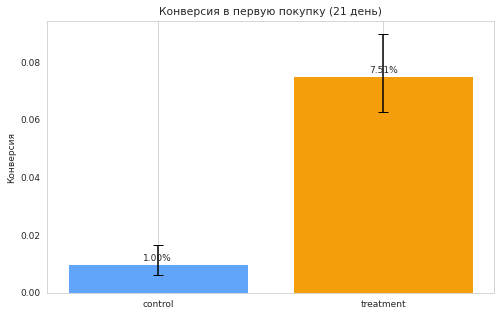

In [ ]:
# Визуализация конверсии с доверительными интервалами: оценка надёжности наблюдаемого эффекта

# Цель: показать не только точечные оценки конверсии, но и 
# диапазон неопределённости, чтобы бизнес понимал риски принятия решения

# 1. Расчёт доверительных интервалов методом Вильсона
# Метод Вильсона предпочтительнее нормального приближения для пропорций,
# особенно при небольших выборках или экстремальных значениях конверсии
# Уровень доверия: 95% (alpha=0.05) — стандарт для продуктовых экспериментов
ci_low, ci_high = [], []
for _, row in results.iterrows():
    low, high = proportion_confint(row['purchasers'], row['users'], alpha=0.05, method='wilson')
    ci_low.append(low)
    ci_high.append(high)

# Добавляем границы интервалов в таблицу результатов для удобства
results['ci_low'] = ci_low
results['ci_high'] = ci_high

# 2. Построение столбчатой диаграммы с ошибками
# Столбцы показывают точечные оценки конверсии, «усы» — 95% доверительные интервалы
# Если интервалы не пересекаются — разница между группами статистически надёжна
plt.figure(figsize=(8, 5))
bars = plt.bar(results['group'], results['conversion'], color=['#60a5fa', '#f59e0b'])

# 3. Добавление «усов» доверительных интервалов
# Асимметричные ошибки: Вильсон даёт несимметричные интервалы, поэтому передаём отдельно
# нижнюю и верхнюю границы отклонения от точечной оценки
plt.errorbar(
    results['group'],
    results['conversion'],
    yerr=[results['conversion'] - results['ci_low'], results['ci_high'] - results['conversion']],
    fmt='none', ecolor='black', capsize=5
)

# Подписи
for bar, conv in zip(bars, results['conversion']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{conv:.2%}', ha='center')

# 5. Оформление графика
plt.title('Конверсия в первую покупку (21 день)')
plt.ylabel('Конверсия')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Выводы по этапу 5: Результаты A/B-теста и рекомендации

---

#### Цель и гипотеза эксперимента

**Цель**: оценить влияние бонуса на первую покупку на конверсию и выручку среди новых пользователей, привлечённых через канал TikTok.

**Гипотеза**: предоставление бонуса на первую покупку новым пользователям TikTok приведёт к увеличению конверсии в покупку.

---

#### Ключевые результаты (21-дневный горизонт)

| Метрика | Контроль (A) | Тест (B) | Абс. прирост | Отн. прирост |
|---------|-------------|----------|--------------|--------------|
| **Конверсия** | 1,00% | 7,51% | +6,51 п.п. | +651% |
| **ARPU** | 12,18 ₽ | 131,25 ₽ | +119,07 ₽ | +977% |
| **ARPPU** | 1 220,89 ₽ | 1 748,00 ₽ | +527,11 ₽ | +43% |
| **AOV** | 15 924,60 ₽ | 16 647,61 ₽ | +723,01 ₽ | +4,5% |

**Статистическая значимость**:
- Конверсия: **p < 0,000001** → эффект значим
- ARPU: **p < 0,0001** → эффект значим

---

#### Подтверждение гипотезы

Гипотеза полностью подтверждена:

1.  **Конверсия выросла в 7,5 раз** — бонус эффективно стимулирует первую покупку
2.  **Качество покупок не пострадало**:
    - Средний чек (AOV) вырос на **4,5%** — пользователи не переключились на дешёвые товары
    - Выручка с покупателя (ARPPU) выросла на **43%** — бонус привлекает более «глубоких» клиентов
3.  **Общая монетизация канала улучшилась**: ARPU вырос почти в **11 раз**

> **Инсайт**: бонус работает не как стимул для импульсивных мелких покупок, а как инструмент привлечения более качественных клиентов, склонных к крупным тратам.

---

#### Рекомендации для бизнеса

**1. Масштабирование (приоритет: высокий)**
- Запустить бонус массово для всех новых пользователей TikTok
- **Условие рентабельности**: стоимость бонуса < 119 ₽ на пользователя (чистый прирост ARPU)

**2. Оптимизация (приоритет: средний)**
- Провести тест вариаций бонуса: **5%**, **10%**, **фиксированная сумма** — для поиска точки максимального ROI
- Продлить горизонт наблюдения до **60–90 дней**, чтобы оценить:
  - Влияние на удержание (переход в сегмент `regular` через 2 месяца)
  - Эффект «отложенного спроса»: покупают ли пользователи только из-за бонуса или формируют лояльность

**3. Ограничения эксперимента (учесть при интерпретации)**
| Ограничение | Риск | Как смягчить |
|-------------|------|--------------|
| Не проводился расчёт статистической мощности | Возможна переоценка эффекта | При масштабировании — запустить валидационный тест с корректным power analysis |
| Горизонт 21 день | Не видим отложенный спрос и удержание | Добавить когортный анализ на 60–90 дней для принявших бонус |
| Только канал TikTok | Результаты не обобщаются на другие каналы | Перед расширением на другие источники — провести пилоты с адаптацией механики |

---

#### Итог для принятия решений

| Проблема | Решение | Ожидаемый эффект |
|----------|---------|-----------------|
| Низкая конверсия TikTok (CR = 1,8–4,9%) | Бонус на первую покупку | Рост CR до **7,5%**, увеличение ARPU в **11×** |
| Низкое качество трафика | Бонус фильтрует аудиторию: привлекает тех, кто готов покупать | Рост ARPPU на **43%**, AOV на **4,5%** |
| Неопределённость в размере стимула | Тест вариаций бонуса | Поиск оптимального ROI без переплаты |


> **Финальный вывод**: бонус на первую покупку — рентабельный инструмент масштабирования трафика из TikTok при условии контроля стоимости стимула. Стратегия превращает низкоконверсионный канал в источник высокомаржинальных клиентов.